# ICA (Intelligent Credit Analyst): Pre-processing → Modelling → Dashboard
**Capstone MVP** · satu notebook, data di-load **sekali** dan semua section memakai variabel di memori.

| Model | Unit | Label | Definisi |
|---|---|---|---|
| Credit Risk new applicant | 1 aplikasi | `default_12m` | DPD ≥ 90 dalam 12 bulan setelah pencairan |
| Credit Risk existing customer | 1 aplikasi | `default_12m` | sama |
| Early Warning | 1 nasabah-bulan | `deterioration_next_1m` | bucket DPD bulan depan memburuk (0 / 1–29 / 30–59 / 60–89 / 90+) |

**Daftar isi**
0. Setup & framework guardrail
1. Load data + **Input Guardrail** (kontrak data, PII, fingerprint)
2. Cek kualitas data
3. Pre-processing
4. EDA
5. Ringkasan insight EDA
6. Feature engineering + **Process Guardrail** (point-in-time)
7. Set fitur, split & feature selection + **Process Guardrail** (leakage, fairness)
8. Modelling: LogReg vs Random Forest vs XGBoost, baseline vs FE + **Process Guardrail** (quality gate)
9. Interpretabilitas
10. **Output Guardrail** (validitas skor, OOD, zona *Further Review*, fairness)
11. **Monitoring & Audit** (drift baseline PSI, model card, simpan artefak)
12. Dashboard optimasi threshold & bisnis
13. Ringkasan guardrail & rencana untuk GenAI / Agentic AI

### Framework AI Guardrail ICA
Empat tahap guardrail diterapkan di tiga lapisan sistem. **Notebook ini mengimplementasikan lapisan Data & ML.**
Lapisan GenAI dan Agentic AI dirancang di sini dan diimplementasikan di notebook berikutnya.

| Tahap | Data & ML (notebook ini) | GenAI (berikutnya) | Agentic AI (berikutnya) |
|---|---|---|---|
| **Input** | Kontrak skema & rentang, kategori valid, integritas relasi, deteksi & masking PII, fingerprint file | Masking PII sebelum ke LLM, deteksi prompt injection di jawaban interview, batas panjang input | Validasi intent pertanyaan analis, otorisasi peran (RBAC), allowlist customer_id |
| **Process** | Point-in-time (anti-leakage), larangan kolom outcome & atribut sensitif, split per nasabah, seleksi fitur hanya di train, seed & versi, quality gate model | Prompt template terkunci, output JSON terstruktur + validasi skema, suhu rendah, hanya boleh pakai evidence (SHAP + data) | Tools read-only, allowlist tool, batas jumlah langkah & waktu, tidak ada aksi tulis/keputusan |
| **Output** | Skor valid [0,1], kebijakan threshold, flag out-of-distribution, zona *Further Review*, cek disparitas (four-fifths rule) | Cek grounding (angka di narasi = angka di data), tanpa PII, bahasa netral, disclaimer "bukan keputusan" | Jawaban wajib menyertakan evidence & sumber tool, keputusan akhir tetap di analis |
| **Monitoring & Audit** | Audit log JSONL per run, drift baseline (PSI), model card, ringkasan lolos/gagal | Log prompt & respons (ter-masking), tingkat penolakan guardrail, feedback analis | Log setiap pemanggilan tool + parameter, jejak keputusan analis, alert anomali |

Prinsip: **fail-closed** (cek kritis yang gagal menghentikan pipeline), **human-in-the-loop** (ICA hanya alat bantu,
keputusan Approve / Reject / Further Review ada di credit analyst), dan **traceable** (setiap cek tercatat di audit log).

In [1]:
# ==== SETUP: lokasi data & artefak (sama di semua notebook) ====
# Urutan pencarian data:
#   1) env ICA_DATA_DIR  2) folder kerja (cwd)  3) /content (hasil "Upload to Colab")
#   4) Google Drive yang sudah di-mount (/content/drive/MyDrive)  5) download otomatis dari link Drive
import os, sys, subprocess, zipfile, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

DRIVE_FILE_ID = "14_4YHSpdbhrmlyaLFpIb556I-f_9cybs"   # ICA_Synthetic_v4.zip di Google Drive
DATA_FOLDER = "ICA_Synthetic_v4"
REQUIRED = ["customer_profile.csv", "credit_application.csv", "credit_account.csv",
            "applicant_interview.csv", "monthly_behavior.csv"]
IN_COLAB = Path("/content").exists()


def _ok(p):
    return p.is_dir() and all((p / f).exists() for f in REQUIRED)


def locate_data():
    roots = [Path(os.environ["ICA_DATA_DIR"])] if os.environ.get("ICA_DATA_DIR") else []
    for b in [Path.cwd(), Path("/content"), Path("/content/drive/MyDrive"), Path("/content/ica_data")]:
        roots += [b, b / DATA_FOLDER, b / "data"]
    for r in roots:
        if _ok(r):
            return r
    dl = (Path("/content") if IN_COLAB else Path.cwd()) / "ica_data"
    found = [p for p in dl.rglob("*") if _ok(p)] if dl.exists() else []
    if found:
        return found[0]
    dl.mkdir(parents=True, exist_ok=True)
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown
    out = dl / "ica_dataset.zip"
    print("Data tidak ditemukan di runtime -> download dari Google Drive ...")
    gdown.download(id=DRIVE_FILE_ID, output=str(out), quiet=False)
    if zipfile.is_zipfile(out):
        zipfile.ZipFile(out).extractall(dl)
    found = [p for p in [dl, *dl.rglob("*")] if _ok(p)]
    if not found:
        raise FileNotFoundError("Data tidak ditemukan. Pastikan link Drive berisi ICA_Synthetic_v4.zip "
                                "dan aksesnya 'Anyone with the link', atau set env ICA_DATA_DIR.")
    return found[0]


DATA_DIR = locate_data()
ART_DIR = DATA_DIR / "ica_artifacts"          # semua output antar-notebook disimpan di sini
ART_DIR.mkdir(exist_ok=True)
print("DATA_DIR:", DATA_DIR)
print("ART_DIR :", ART_DIR)

# ---- gaya grafik (satu palet untuk semua notebook) ----
import matplotlib.pyplot as plt
import seaborn as sns
C_GOOD, C_BAD, C_3 = "#2a78d6", "#eb6834", "#1baf7a"     # lancar | default/alert | seri ke-3
MODEL_COLORS = {"LogReg": "#2a78d6", "RandomForest": "#eb6834", "XGBoost": "#1baf7a"}
FS_COLORS = {"baseline": "#2a78d6", "fe": "#eb6834"}
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e", "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": .6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.frameon": False, "legend.fontsize": 8, "font.family": "sans-serif",
})

DATA_DIR: /content/ica_data/ICA_Synthetic_v4
ART_DIR : /content/ica_data/ICA_Synthetic_v4/ica_artifacts


## 0. Framework guardrail & audit log
Setiap cek guardrail dicatat ke `audit_log.jsonl` dengan atribut `layer` (Data / ML / GenAI / Agent),
`stage` (Input / Process / Output / Monitoring), status (`pass` / `warn` / `fail`), dan detail.
- `fail` pada cek kritis menghentikan notebook (**fail-closed**), jadi model tidak pernah dilatih di atas data yang rusak.
- `warn` dicatat dan ditampilkan, tapi pipeline lanjut.

In [2]:
import json, hashlib, platform, datetime as dt, uuid
import numpy as np
import pandas as pd
import sklearn

STRICT = True                       # True = fail-closed
RUN_ID = dt.datetime.now().strftime("%Y%m%d-%H%M%S") + "-" + uuid.uuid4().hex[:6]


class GuardrailError(RuntimeError):
    pass


class AuditLog:
    def __init__(self, path, run_id):
        self.path, self.run_id, self.records = Path(path), run_id, []

    def log(self, layer, stage, check, status, detail="", **extra):
        rec = {"ts": dt.datetime.now().isoformat(timespec="seconds"), "run_id": self.run_id, "layer": layer,
               "stage": stage, "check": check, "status": status, "detail": str(detail), **extra}
        self.records.append(rec)
        with self.path.open("a", encoding="utf-8") as f:
            f.write(json.dumps(rec, ensure_ascii=False, default=str) + "\n")
        return rec

    def frame(self):
        return pd.DataFrame(self.records)


AUDIT = AuditLog(ART_DIR / "audit_log.jsonl", RUN_ID)
ICON = {"pass": "✅", "warn": "⚠️", "fail": "❌"}


def guard(layer, stage, check, ok, detail="", severity="fail", quiet=False):
    """Catat satu cek guardrail. severity='fail' → hentikan pipeline bila gagal (kalau STRICT)."""
    status = "pass" if ok else severity
    AUDIT.log(layer, stage, check, status, detail)
    if not quiet or not ok:
        print(f"{ICON[status]} [{layer}·{stage}] {check}" + (f" — {detail}" if detail else ""))
    if status == "fail" and STRICT:
        raise GuardrailError(f"Guardrail gagal: {check} ({detail})")
    return ok


AUDIT.log("System", "Monitoring", "run_started", "pass",
          detail=f"python {platform.python_version()} · pandas {pd.__version__} · sklearn {sklearn.__version__}")
print("RUN_ID:", RUN_ID)

RUN_ID: 20261007-142656-eca770


In [3]:
import numpy as np
import pandas as pd
import joblib
from IPython.display import display

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Load data & Input Guardrail

In [4]:
cp = pd.read_csv(DATA_DIR / "customer_profile.csv", parse_dates=["customer_since"])
ap = pd.read_csv(DATA_DIR / "credit_application.csv", parse_dates=["application_date", "disbursement_date"])
ac = pd.read_csv(DATA_DIR / "credit_account.csv", parse_dates=["open_date", "close_date"])
iv = pd.read_csv(DATA_DIR / "applicant_interview.csv", parse_dates=["interview_date"])
mb = pd.read_csv(DATA_DIR / "monthly_behavior.csv", parse_dates=["snapshot_date"])
tables = {"customer_profile": cp, "credit_application": ap, "credit_account": ac,
          "applicant_interview": iv, "monthly_behavior": mb}

overview = pd.DataFrame([{
    "tabel": k, "baris": len(v), "kolom": v.shape[1],
    "sel_missing": int(v.isna().sum().sum()), "baris_duplikat": int(v.duplicated().sum()),
} for k, v in tables.items()])
display(overview)

,tabel,baris,kolom,sel_missing,baris_duplikat
0,customer_profile,12000,13,0,0
1,credit_application,12000,14,0,0
2,credit_account,21990,13,28420,0
3,applicant_interview,24000,12,0,0
4,monthly_behavior,192000,20,41179,0


In [5]:
for k, v in tables.items():
    print(f"\n=== {k} ===")
    display(v.head(3))


=== customer_profile ===


,customer_id,customer_status,age,gender,marital_status,dependents,employment_type,employment_tenure_months,monthly_income,income_source,customer_since,city,customer_segment
0,CUST00001,existing,40,Male,Married,1,Self-employed,126,"43,627,000.0000",Business,2017-08-31,Surabaya,Affluent
1,CUST00002,existing,26,Female,Married,2,Salaried,45,"4,878,000.0000",Salary,2018-05-30,Bandung,Mass
2,CUST00003,existing,35,Male,Married,0,Self-employed,15,"4,585,000.0000",Business,2017-01-05,Jakarta,Mass



=== credit_application ===


,application_id,customer_id,customer_status,application_date,loan_type,loan_purpose,requested_amount,tenor_months,interest_rate,monthly_installment,existing_monthly_debt,application_channel,disbursement_date,default_12m
0,APP00001,CUST00001,existing,2024-12-02,Business Loan,Working Capital,"15,000,000.0000",48,11.5100,"391,000.0000","26,675,000.0000",Referral,2024-12-14,0
1,APP00002,CUST00002,existing,2024-07-03,Home Loan,Home Purchase,"164,800,000.0000",120,8.8700,"2,076,000.0000","814,000.0000",Branch,2024-07-08,0
2,APP00003,CUST00003,existing,2024-07-21,Auto Loan,Vehicle Purchase,"88,200,000.0000",36,9.8700,"2,841,000.0000","131,000.0000",Branch,2024-07-24,1



=== credit_account ===


,account_id,customer_id,application_id,product_type,open_date,close_date,credit_limit,outstanding,interest_rate,tenor_months,monthly_installment,account_status,days_past_due
0,ACC00001,CUST02629,NaN,Credit Card,2016-01-02,NaT,"41,000,000.0000","7,143,046.0000",25.7800,0,"357,000.0000",Active,0
1,ACC00002,CUST03543,NaN,Credit Card,2016-01-02,NaT,"19,000,000.0000","7,756,850.0000",21.3700,0,"388,000.0000",Active,0
2,ACC00003,CUST06000,NaN,Credit Card,2016-01-02,NaT,"21,000,000.0000","4,628,278.0000",19.1000,0,"231,000.0000",Active,21



=== applicant_interview ===


,interview_id,application_id,question_id,question,response_text,interview_date,income_trend,income_stability,existing_debt_level,repayment_issue,financial_change,business_condition
0,INT00001,APP08001,Q01,Bagaimana kondisi pendapatan Anda dalam bebera...,"Tren pendapatan saya membaik, sekarang di angk...",2024-11-25,increasing,high,medium,none,stable,not_applicable
1,INT00001,APP08001,Q02,Apakah saat ini Anda memiliki cicilan atau kew...,"Oke, ada 2 cicilan, cicilan motor dan cicilan ...",2024-11-25,increasing,high,medium,none,stable,not_applicable
2,INT00001,APP08001,Q03,Bagaimana riwayat pembayaran cicilan Anda sebe...,"Kalau itu, lancar terus, belum pernah nunggak.",2024-11-25,increasing,high,medium,none,stable,not_applicable



=== monthly_behavior ===


,customer_id,snapshot_date,total_outstanding,total_credit_limit,credit_utilization,total_monthly_payment,total_amount_due,payment_ratio,dpd,late_payment_count,missed_payment_count,overdue_amount,active_accounts,new_credit_accounts,outstanding_change_1m,payment_ratio_change_1m,max_dpd_3m,avg_utilization_3m,deterioration_next_1m,default_next_3m
0,CUST00001,2024-01-31,"210,951,977.0000","935,900,000.0000",0.2254,"9,016,955.0000","20,481,046.0000",0.4403,30,0,1,"20,481,046.0000",2,0,0.0000,0.0000,30,0.2254,0.0000,0.0000
1,CUST00001,2024-02-29,"198,951,192.0000","935,900,000.0000",0.2126,"17,827,326.0000","20,705,103.0000",0.8610,35,0,1,"20,705,103.0000",2,0,-0.0569,0.4207,35,0.2190,0.0000,0.0000
2,CUST00001,2024-03-31,"180,615,627.0000","935,900,000.0000",0.1930,"12,216,454.0000","20,618,266.0000",0.5925,31,1,1,"29,020,077.0000",2,0,-0.0922,-0.2685,35,0.2103,0.0000,0.0000


### 1.1 Input Guardrail: kontrak data
Setiap tabel harus memenuhi kontrak: kolom wajib ada, kunci unik, rentang numerik masuk akal, dan nilai kategori
sesuai daftar yang diizinkan. Kalau data baru (misalnya data test eksternal) melanggar kontrak, pipeline berhenti
sebelum masuk ke model.

In [6]:
CONTRACT = {
    "customer_profile": {
        "key": ["customer_id"],
        "num": {"age": (18, 75), "dependents": (0, 10), "employment_tenure_months": (0, 600),
                "monthly_income": (5e5, 1e10)},
        "cat": {"customer_status": {"new", "existing"},
                "employment_type": {"Salaried", "Business Owner", "Self-employed", "Contract"},
                "income_source": {"Salary", "Business", "Mixed"},
                "customer_segment": {"Mass", "Upper Mass", "Affluent"}},
        "not_null": ["customer_id", "customer_status", "monthly_income", "employment_type"]},
    "credit_application": {
        "key": ["application_id"],
        "num": {"requested_amount": (1e6, 1e11), "tenor_months": (1, 360), "interest_rate": (0, 40),
                "monthly_installment": (1, 1e10), "existing_monthly_debt": (0, 1e10)},
        "cat": {"loan_type": {"Personal Loan", "Business Loan", "Auto Loan", "Home Loan"},
                "application_channel": {"Branch", "Online", "Referral"}, "default_12m": {0, 1}},
        "not_null": ["application_id", "customer_id", "application_date", "requested_amount", "default_12m"]},
    "credit_account": {
        "key": ["account_id"],
        "num": {"credit_limit": (0, 1e11), "outstanding": (0, 1e11), "interest_rate": (0, 40),
                "days_past_due": (0, 3000)},
        "cat": {"account_status": {"Active", "Closed", "Delinquent", "Default"},
                "product_type": {"Credit Card", "Personal Loan", "Business Loan", "Auto Loan", "Home Loan"}},
        "not_null": ["account_id", "customer_id", "open_date"]},
    "applicant_interview": {
        "key": ["interview_id", "question_id"],
        "num": {},
        "cat": {"question_id": {f"Q0{i}" for i in range(1, 7)}},
        "not_null": ["interview_id", "application_id", "question_id", "response_text"]},
    "monthly_behavior": {
        "key": ["customer_id", "snapshot_date"],
        "num": {"credit_utilization": (0, 1), "payment_ratio": (0, 5), "dpd": (0, 3000),
                "total_outstanding": (0, 1e12)},
        "cat": {"deterioration_next_1m": {0.0, 1.0}},
        "not_null": ["customer_id", "snapshot_date", "dpd", "payment_ratio"]},
}

for tname, rule in CONTRACT.items():
    df = tables[tname]
    cols = set(rule["key"]) | set(rule["num"]) | set(rule["cat"]) | set(rule["not_null"])
    missing_cols = sorted(cols - set(df.columns))
    guard("Data", "Input", f"{tname}: kolom wajib ada", not missing_cols, missing_cols or "")
    guard("Data", "Input", f"{tname}: kunci unik {rule['key']}", not df.duplicated(rule["key"]).any(), quiet=True)
    nn = {c: int(df[c].isna().sum()) for c in rule["not_null"] if df[c].isna().any()}
    guard("Data", "Input", f"{tname}: kolom wajib tidak kosong", not nn, nn or "", quiet=True)
    bad_rng = {c: int((~df[c].between(lo, hi)).sum()) for c, (lo, hi) in rule["num"].items()
               if (~df[c].between(lo, hi)).any()}
    guard("Data", "Input", f"{tname}: rentang numerik", not bad_rng, bad_rng or "", quiet=True)
    bad_cat = {c: sorted(set(df[c].dropna().unique()) - allowed)[:5] for c, allowed in rule["cat"].items()
               if set(df[c].dropna().unique()) - allowed}
    guard("Data", "Input", f"{tname}: kategori valid", not bad_cat, bad_cat or "", quiet=True)
print("Kontrak data: semua tabel lolos.")

✅ [Data·Input] customer_profile: kolom wajib ada
✅ [Data·Input] credit_application: kolom wajib ada
✅ [Data·Input] credit_account: kolom wajib ada
✅ [Data·Input] applicant_interview: kolom wajib ada
✅ [Data·Input] monthly_behavior: kolom wajib ada
Kontrak data: semua tabel lolos.


### 1.2 Input Guardrail: deteksi & masking PII
Data kredit sensitif. Dua lapis pengecekan:
1. **Nama kolom**: tidak boleh ada kolom identitas langsung (nama, NIK/KTP, telepon, email, alamat).
2. **Teks bebas** (jawaban interview): dipindai pola NIK (16 digit), nomor HP, email, dan nomor rekening.
   Fungsi `mask_pii()` juga dipakai nanti **sebelum teks dikirim ke LLM** (guardrail input GenAI).

In [7]:
import re

PII_COL = re.compile(r"(^|_)(name|nama|nik|ktp|npwp|phone|telp|hp|email|address|alamat|rekening)($|_)", re.I)
PII_PATTERNS = {
    "nik": re.compile(r"\b\d{16}\b"),
    "phone": re.compile(r"(\+62|\b0)8\d{7,11}\b"),
    "email": re.compile(r"\b[\w.+-]+@[\w-]+\.[\w.]+\b"),
    "account_no": re.compile(r"\b\d{10,15}\b"),
}


def mask_pii(text):
    """Ganti PII di teks dengan token, kembalikan (teks_ter-masking, jumlah_temuan_per_jenis)."""
    found = {}
    for k, pat in PII_PATTERNS.items():
        text, n = pat.subn(f"[{k.upper()}]", text)
        if n:
            found[k] = n
    return text, found


pii_cols = {t: [c for c in df.columns if PII_COL.search(c)] for t, df in tables.items()}
pii_cols = {t: c for t, c in pii_cols.items() if c}
guard("Data", "Input", "tidak ada kolom PII langsung", not pii_cols, pii_cols or "")

masked = iv.response_text.map(mask_pii)
pii_hits = pd.Series([sum(f.values()) for _, f in masked]).sum()
iv["response_text_masked"] = [t for t, _ in masked]
guard("Data", "Input", "PII di teks interview sudah di-masking", True,
      f"{pii_hits} temuan di-masking dari {len(iv):,} jawaban", severity="warn")
print("Contoh masking:", mask_pii("NIK saya 3171234567890001, hubungi 081234567890 atau budi@mail.com")[0])

✅ [Data·Input] tidak ada kolom PII langsung
✅ [Data·Input] PII di teks interview sudah di-masking — 0 temuan di-masking dari 24,000 jawaban
Contoh masking: NIK saya [NIK], hubungi [PHONE] atau [EMAIL]


### 1.3 Monitoring: fingerprint data (lineage)
Hash SHA-256 setiap file dicatat di audit log. Hasil model bisa ditelusuri ke versi data persis yang dipakai.

In [8]:
def sha256(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""):
            h.update(b)
    return h.hexdigest()


fingerprint = {f: {"sha256": sha256(DATA_DIR / f)[:16], "rows": len(tables[f[:-4]])} for f in REQUIRED}
AUDIT.log("Data", "Monitoring", "data_fingerprint", "pass", json.dumps(fingerprint))
display(pd.DataFrame(fingerprint).T)

,sha256,rows
customer_profile.csv,3a2a864ef08a3d8d,12000
credit_application.csv,ad1b18c77819043e,12000
credit_account.csv,9cce8603eb2c0fc3,21990
applicant_interview.csv,1751040b6fa3ca4c,24000
monthly_behavior.csv,23f7bb1d683392ce,192000


## 2. Cek kualitas data
### 2.1 Missing value
Missing yang **diharapkan**:
- `credit_account.close_date`: akun belum ditutup
- `monthly_behavior.deterioration_next_1m` / `default_next_3m`: bulan terakhir (tidak ada masa depan) atau nasabah sudah default

In [9]:
miss = []
for k, v in tables.items():
    s = v.isna().sum()
    for col, n in s[s > 0].items():
        miss.append({"tabel": k, "kolom": col, "missing": n, "pct": n / len(v) * 100})
miss = pd.DataFrame(miss)
display(miss)

# label EW kosong: cek bahwa penyebabnya memang bulan terakhir atau sudah default
lab_na = mb[mb.deterioration_next_1m.isna()]
print("Label EW kosong karena bulan terakhir :", (lab_na.snapshot_date == mb.snapshot_date.max()).sum())
print("Label EW kosong karena sudah default  :", (lab_na.dpd >= 90).sum())
print("Label EW kosong karena hal lain       :", ((lab_na.snapshot_date != mb.snapshot_date.max()) & (lab_na.dpd < 90)).sum())

,tabel,kolom,missing,pct
0,credit_account,application_id,9990,45.4297
1,credit_account,close_date,18430,83.8108
2,monthly_behavior,deterioration_next_1m,13283,6.9182
3,monthly_behavior,default_next_3m,27896,14.5292


Label EW kosong karena bulan terakhir : 8000
Label EW kosong karena sudah default  : 5982
Label EW kosong karena hal lain       : 0


### 2.2 Kunci unik, integritas relasi, aturan bisnis & konsistensi label

In [10]:
checks = []


def check(name, cond):
    checks.append({"cek": name, "lolos": bool(cond)})


check("customer_id unik", cp.customer_id.is_unique)
check("application_id unik", ap.application_id.is_unique)
check("account_id unik", ac.account_id.is_unique)
check("(customer_id, snapshot_date) unik", not mb.duplicated(["customer_id", "snapshot_date"]).any())
check("(interview_id, question_id) unik", not iv.duplicated(["interview_id", "question_id"]).any())
check("aplikasi → profil ada", ap.customer_id.isin(cp.customer_id).all())
check("akun → profil ada", ac.customer_id.isin(cp.customer_id).all())
check("akun hasil aplikasi → aplikasi ada", ac.application_id.dropna().isin(ap.application_id).all())
check("interview hanya untuk new applicant",
      ap.set_index("application_id").loc[iv.application_id.unique(), "customer_status"].eq("new").all())
check("monthly hanya untuk existing",
      cp.set_index("customer_id").loc[mb.customer_id.unique(), "customer_status"].eq("existing").all())
check("umur 21–60", cp.age.between(21, 60).all())
check("penghasilan > 0", (cp.monthly_income > 0).all())
check("plafon & cicilan > 0", (ap.requested_amount > 0).all() and (ap.monthly_installment > 0).all())
check("tanggal cair ≥ tanggal aplikasi", (ap.disbursement_date >= ap.application_date).all())
check("close_date ≥ open_date", (ac.close_date.dropna() >= ac.open_date[ac.close_date.notna()]).all())
check("utilisasi 0–1", mb.credit_utilization.between(0, 1).all())
check("DPD ≥ 0", (mb.dpd >= 0).all() and (ac.days_past_due >= 0).all())
lab = ap.merge(ac[["application_id", "account_status", "days_past_due"]], on="application_id")
check("default_12m=1 ⇔ akun hasil aplikasi berstatus Default",
      ((lab.default_12m == 1) == (lab.account_status == "Default")).all())
display(pd.DataFrame(checks))
for c in checks:
    guard("Data", "Input", c["cek"], c["lolos"], quiet=True)
print(f"{len(checks)} cek kualitas & integritas: semua lolos.")

,cek,lolos
0,customer_id unik,True
1,application_id unik,True
2,account_id unik,True
3,"(customer_id, snapshot_date) unik",True
4,"(interview_id, question_id) unik",True
5,aplikasi → profil ada,True
6,akun → profil ada,True
7,akun hasil aplikasi → aplikasi ada,True
8,interview hanya untuk new applicant,True
9,monthly hanya untuk existing,True


18 cek kualitas & integritas: semua lolos.


### 2.3 Outlier
Nilai ekstrem dicek dengan aturan IQR. Nilai seperti penghasilan tinggi atau plafon KPR besar adalah **nilai valid**, bukan error,
jadi tidak dibuang. Kemiringan (skew) ditangani di section 6–7 dengan transformasi log dan rasio (DSR, LTI).

In [11]:
def iqr_outliers(s):
    q1, q3 = s.quantile([.25, .75])
    return ((s < q1 - 1.5 * (q3 - q1)) | (s > q3 + 1.5 * (q3 - q1))).mean() * 100


num_cols = {"customer_profile": ["age", "dependents", "employment_tenure_months", "monthly_income"],
            "credit_application": ["requested_amount", "tenor_months", "interest_rate", "monthly_installment",
                                   "existing_monthly_debt"],
            "monthly_behavior": ["credit_utilization", "payment_ratio", "dpd", "overdue_amount", "total_outstanding"]}
out = []
for t, cols in num_cols.items():
    for c in cols:
        s = tables[t][c]
        out.append({"tabel": t, "kolom": c, "min": s.min(), "median": s.median(), "max": s.max(),
                    "skew": s.skew(), "%outlier_IQR": iqr_outliers(s)})
display(pd.DataFrame(out).round(2))

,tabel,kolom,min,median,max,skew,%outlier_IQR
0,customer_profile,age,21.0000,37.0000,60.0000,0.1300,0.0000
1,customer_profile,dependents,0.0000,1.0000,4.0000,0.8600,0.0000
2,customer_profile,employment_tenure_months,3.0000,41.0000,396.0000,1.6600,4.3800
3,customer_profile,monthly_income,"3,500,000.0000","10,565,000.0000","166,088,000.0000",3.8000,5.8800
4,credit_application,requested_amount,"3,000,000.0000","68,200,000.0000","3,000,000,000.0000",4.3800,10.2700
5,credit_application,tenor_months,12.0000,36.0000,240.0000,2.1600,15.1500
6,credit_application,interest_rate,7.0000,11.8500,18.0000,0.2300,0.0000
7,credit_application,monthly_installment,"98,000.0000","2,585,500.0000","63,485,000.0000",3.7800,6.3100
8,credit_application,existing_monthly_debt,0.0000,"1,161,500.0000","60,344,000.0000",5.5300,7.9800
9,monthly_behavior,credit_utilization,0.0000,0.5700,1.0000,-0.2500,0.0000


## 3. Pre-processing
### 3.1 Interview → satu baris per aplikasi
Tabel interview berisi 6 baris (Q01–Q06) per aplikasi. Label ekstraksi bernilai sama di semua baris interview,
jadi diambil sekali per aplikasi. Transkrip lengkap juga disimpan untuk dipakai GenAI nanti.

In [12]:
IV_LABELS = ["income_trend", "income_stability", "existing_debt_level", "repayment_issue",
             "financial_change", "business_condition"]
iv = iv.sort_values(["interview_id", "question_id"])
iv_wide = iv.groupby("application_id").agg(
    interview_id=("interview_id", "first"), interview_date=("interview_date", "first"),
    **{c: (c, "first") for c in IV_LABELS})
iv_wide["transcript"] = iv.groupby("application_id").apply(
    lambda g: "\n".join(f"[{q}] {qt}\n> {a}" for q, qt, a in zip(g.question_id, g.question, g.response_text)))
iv_wide = iv_wide.reset_index()
print(iv_wide.shape)
print(iv_wide.transcript.iloc[0])

(4000, 10)
[Q01] Bagaimana kondisi pendapatan Anda dalam beberapa bulan terakhir?
> Tren pendapatan saya membaik, sekarang di angka 17,2 juta. Posisi saya cukup aman.
[Q02] Apakah saat ini Anda memiliki cicilan atau kewajiban kredit lain?
> Oke, ada 2 cicilan, cicilan motor dan cicilan mobil, totalnya kira-kira 2 juta sebulan.
[Q03] Bagaimana riwayat pembayaran cicilan Anda sebelumnya?
> Kalau itu, lancar terus, belum pernah nunggak.
[Q04] Apakah ada perubahan kondisi keuangan akhir-akhir ini?
> Hmm, tidak ada perubahan berarti.
[Q05] Apa tujuan utama pengajuan kredit?
> Untuk keperluan darurat, perbaikan rumah karena banjir.
[Q06] Bagaimana kondisi usaha atau pekerjaan Anda saat ini?
> Baik, baru saja dapat penilaian kinerja bagus.


### 3.2 Tabel dasar per model
- **cr_base**: aplikasi + profil (+ label interview untuk new applicant).
- **ew_base**: snapshot bulanan + profil statis. Baris dengan label kosong **tidak** dibuang di sini,
  karena dibutuhkan untuk menghitung fitur lag di section 6–7.

Fitur perilaku untuk Credit Risk existing dibuat di section 6–7 dengan aturan point-in-time
(`snapshot_date < application_date`).

In [13]:
cr_base = ap.merge(cp.drop(columns="customer_status"), on="customer_id", how="left")
cr_base = cr_base.merge(iv_wide[["application_id"] + IV_LABELS], on="application_id", how="left")
ew_base = mb.merge(cp[["customer_id", "age", "employment_type", "employment_tenure_months", "monthly_income",
                       "income_source", "customer_segment", "customer_since", "gender", "city"]], on="customer_id", how="left")
print("cr_base:", cr_base.shape, "| ew_base:", ew_base.shape)

cr_base: (12000, 31) | ew_base: (192000, 29)


## 4. EDA
### 4.1 Distribusi label
Kedua label tidak seimbang (sekitar 10% kelas positif). Karena itu:
- metrik utama **recall** (default/deteriorasi yang tertangkap), ditemani precision dan PR-AUC;
- model memakai **class weight**;
- threshold dipilih dari data, bukan 0,5.

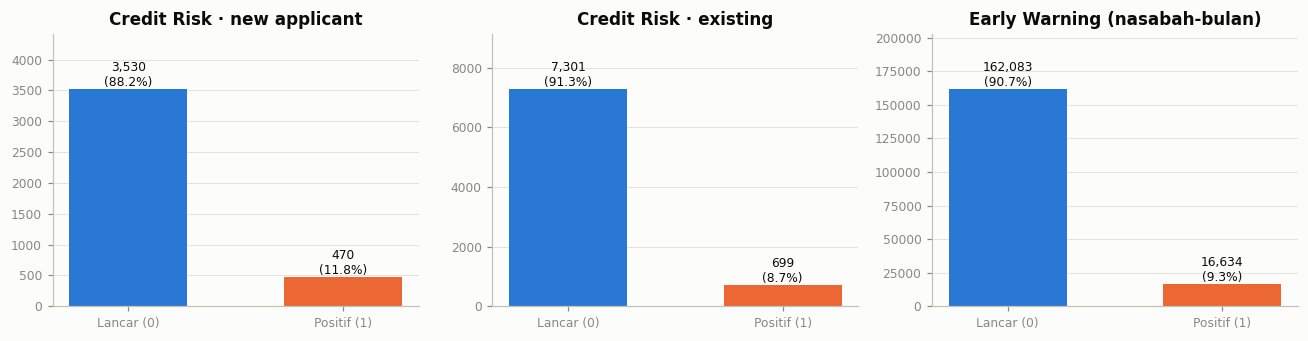

In [14]:
ew_lab = mb.dropna(subset=["deterioration_next_1m"])
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, (title, s) in zip(axes, [
        ("Credit Risk · new applicant", ap.loc[ap.customer_status == "new", "default_12m"]),
        ("Credit Risk · existing", ap.loc[ap.customer_status == "existing", "default_12m"]),
        ("Early Warning (nasabah-bulan)", ew_lab.deterioration_next_1m)]):
    vc = s.value_counts().sort_index()
    bars = ax.bar(["Lancar (0)", "Positif (1)"], vc.values, color=[C_GOOD, C_BAD], width=.55)
    for b, v in zip(bars, vc.values):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,}\n({v / vc.sum():.1%})", ha="center", va="bottom",
                fontsize=8, color=INK)
    ax.set_title(title)
    ax.set_ylim(0, vc.max() * 1.25)
    ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

### 4.2 Credit Risk: variabel numerik
Default rate per desil. Rasio kemampuan bayar (DSR, LTI) dihitung sementara untuk EDA
dan dibuat resmi di section 6–7.

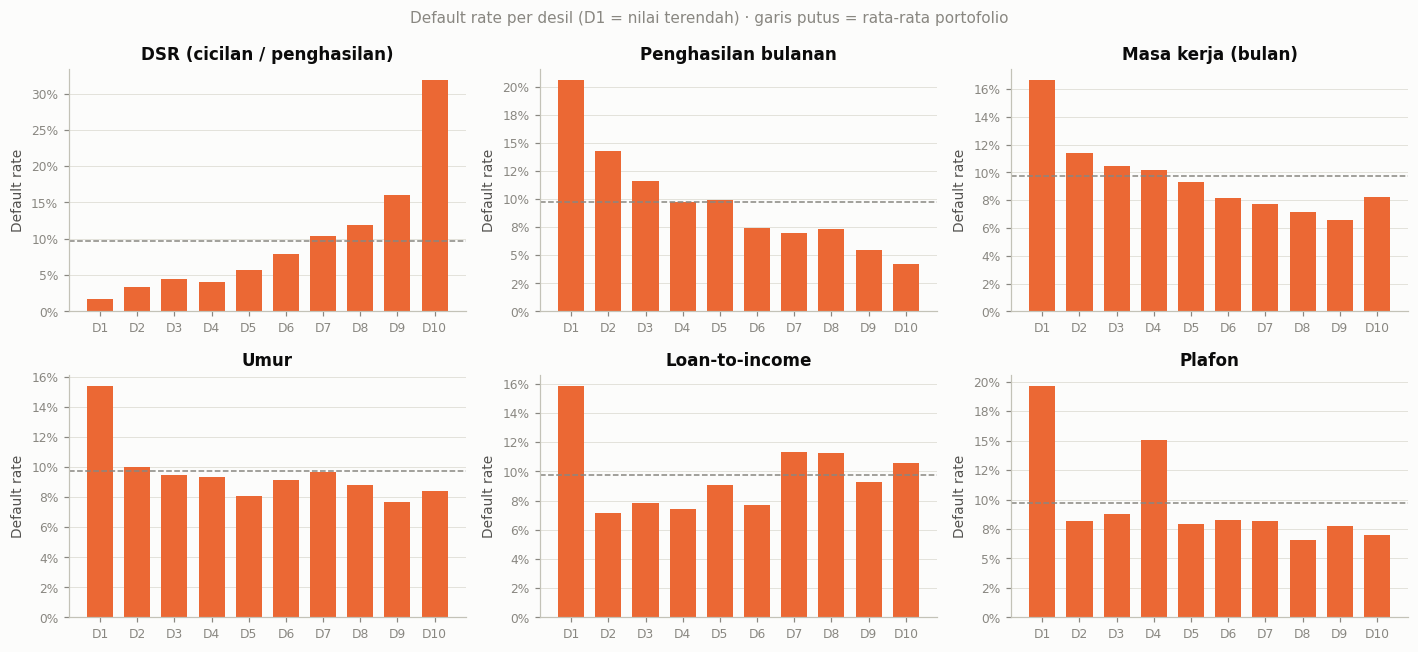

,mean,count
DSR,,
"(0.0659, 0.254]",0.0175,1200
"(0.254, 0.318]",0.0333,1200
"(0.318, 0.358]",0.0450,1200
"(0.358, 0.399]",0.0400,1200
"(0.399, 0.441]",0.0567,1200
"(0.441, 0.484]",0.0792,1200
"(0.484, 0.531]",0.1042,1200
"(0.531, 0.585]",0.1192,1200
"(0.585, 0.653]",0.1608,1200


In [15]:
eda = cr_base.copy()
eda["dsr"] = (eda.monthly_installment + eda.existing_monthly_debt) / eda.monthly_income
eda["lti"] = eda.requested_amount / (eda.monthly_income * 12)
base_rate = eda.default_12m.mean()
vars_num = [("dsr", "DSR (cicilan / penghasilan)"), ("monthly_income", "Penghasilan bulanan"),
            ("employment_tenure_months", "Masa kerja (bulan)"), ("age", "Umur"),
            ("lti", "Loan-to-income"), ("requested_amount", "Plafon")]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, (c, label) in zip(axes.ravel(), vars_num):
    q = pd.qcut(eda[c], 10, duplicates="drop")
    r = eda.groupby(q, observed=True).default_12m.mean()
    ax.bar(range(len(r)), r.values, color=C_BAD, width=.7)
    ax.axhline(base_rate, color=MUTED, ls="--", lw=1)
    ax.set_xticks(range(len(r)))
    ax.set_xticklabels([f"D{i + 1}" for i in range(len(r))])
    ax.set_title(f"{label}")
    ax.set_ylabel("Default rate")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.grid(axis="x", visible=False)
fig.suptitle("Default rate per desil (D1 = nilai terendah) · garis putus = rata-rata portofolio", fontsize=10, color=MUTED)
plt.tight_layout()
plt.show()
display(eda.groupby(pd.qcut(eda.dsr, 10), observed=True).default_12m.agg(["mean", "count"]).rename_axis("DSR"))

### 4.3 Credit Risk: variabel kategorikal
Baris bawah adalah **atribut sensitif** (gender, kota, status nikah). Default rate-nya harus datar.
Atribut ini tidak dipakai sebagai fitur (kebijakan fairness).

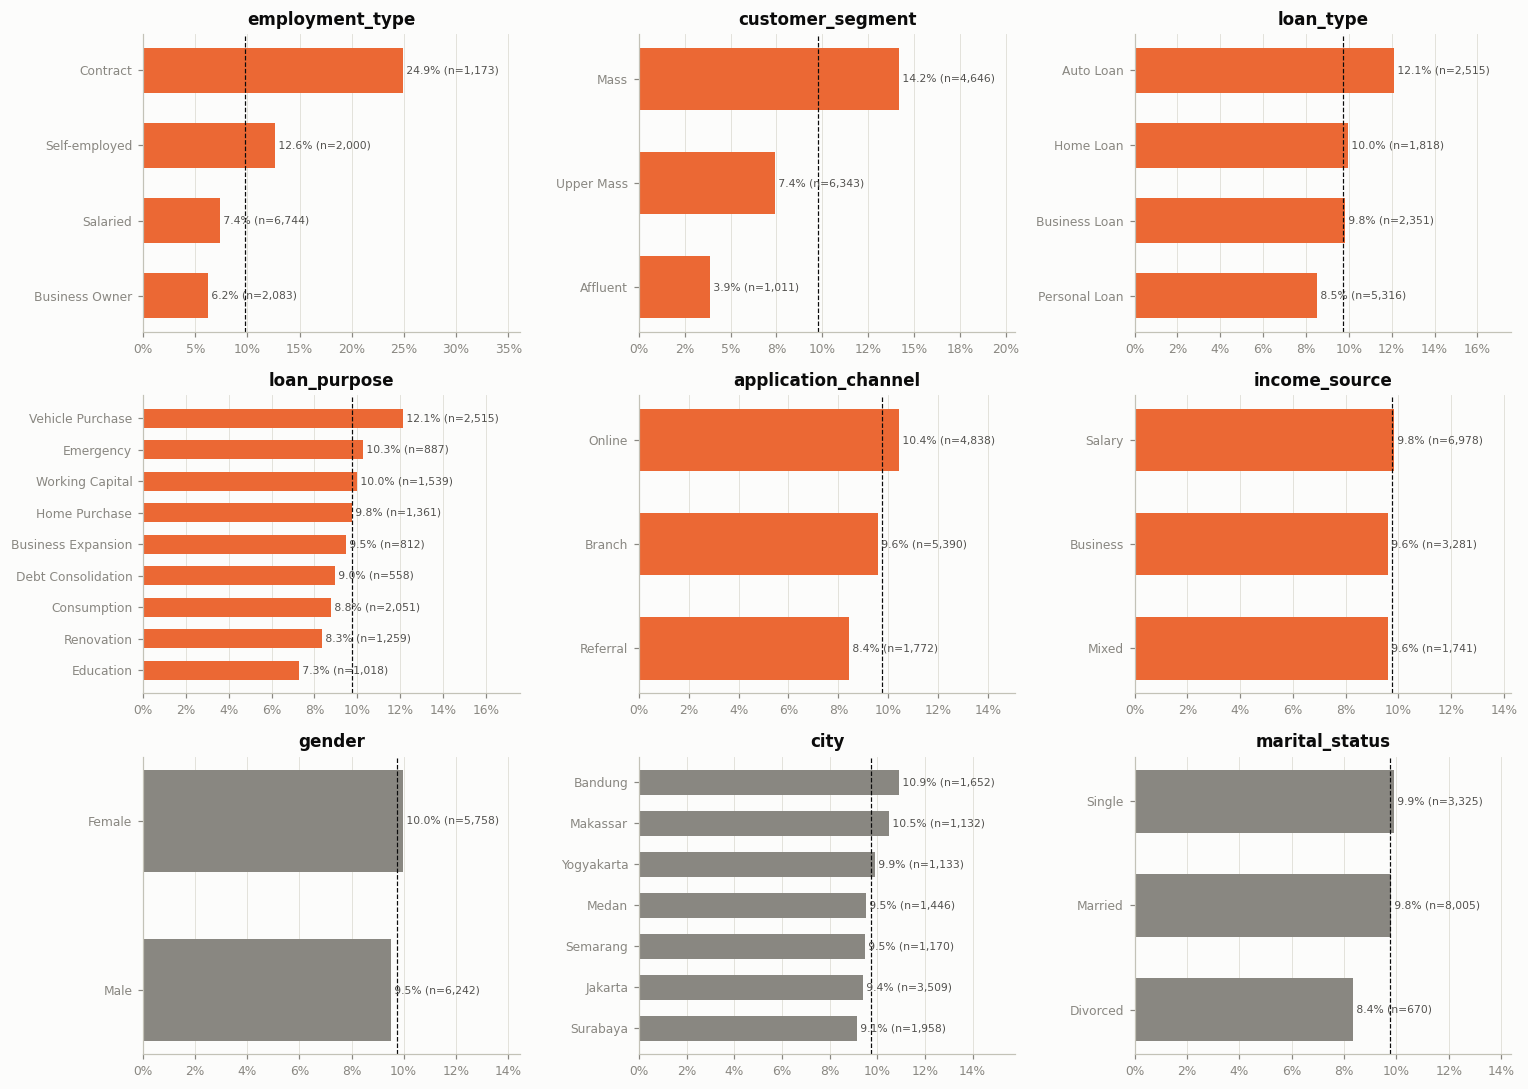

In [16]:
cats = ["employment_type", "customer_segment", "loan_type", "loan_purpose", "application_channel", "income_source",
        "gender", "city", "marital_status"]
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, c in zip(axes.ravel(), cats):
    r = eda.groupby(c).default_12m.agg(["mean", "count"]).sort_values("mean")
    ax.barh(r.index.astype(str), r["mean"], color=C_BAD if c not in ("gender", "city", "marital_status") else MUTED,
            height=.6)
    ax.axvline(base_rate, color=INK, ls="--", lw=.8)
    for y, (m, n) in enumerate(zip(r["mean"], r["count"])):
        ax.text(m, y, f" {m:.1%} (n={n:,})", va="center", fontsize=7, color="#52514e")
    ax.set_title(c)
    ax.set_xlim(0, r["mean"].max() * 1.45)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### 4.4 Credit Risk new applicant: label interview vs default
Setiap label interview harus punya arah risiko yang masuk akal. Ini dasar penjelasan GenAI nanti.

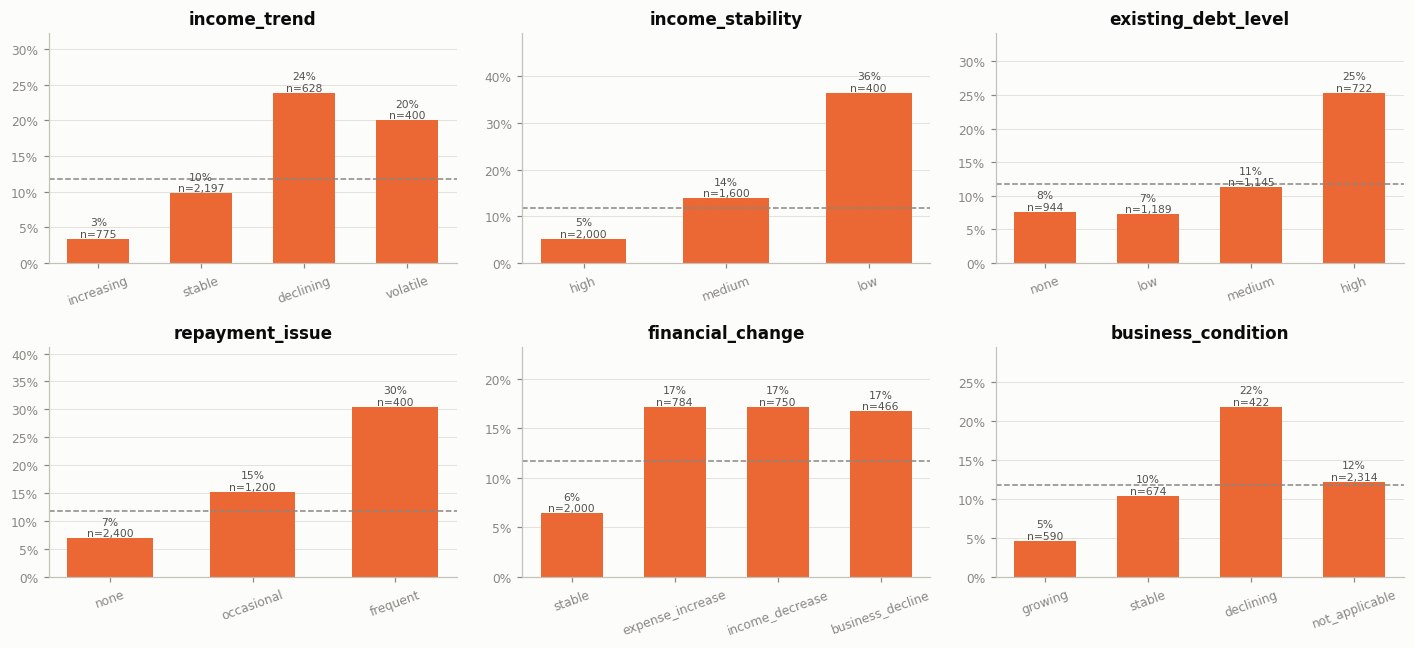

In [17]:
new = eda[eda.customer_status == "new"]
order = {"income_trend": ["increasing", "stable", "declining", "volatile"],
         "income_stability": ["high", "medium", "low"],
         "existing_debt_level": ["none", "low", "medium", "high"],
         "repayment_issue": ["none", "occasional", "frequent"],
         "financial_change": ["stable", "expense_increase", "income_decrease", "business_decline"],
         "business_condition": ["growing", "stable", "declining", "not_applicable"]}
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
nb_rate = new.default_12m.mean()
for ax, (c, o) in zip(axes.ravel(), order.items()):
    r = new.groupby(c).default_12m.agg(["mean", "count"]).reindex(o)
    ax.bar(o, r["mean"], color=C_BAD, width=.6)
    ax.axhline(nb_rate, color=MUTED, ls="--", lw=1)
    for x, (m, n) in enumerate(zip(r["mean"], r["count"])):
        ax.text(x, m, f"{m:.0%}\nn={n:,}", ha="center", va="bottom", fontsize=7, color="#52514e")
    ax.set_title(c)
    ax.set_ylim(0, r["mean"].max() * 1.35)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

### 4.5 Korelasi antar variabel numerik (Credit Risk)
Dipakai untuk mengantisipasi multikolinearitas di feature selection (section 6–7).

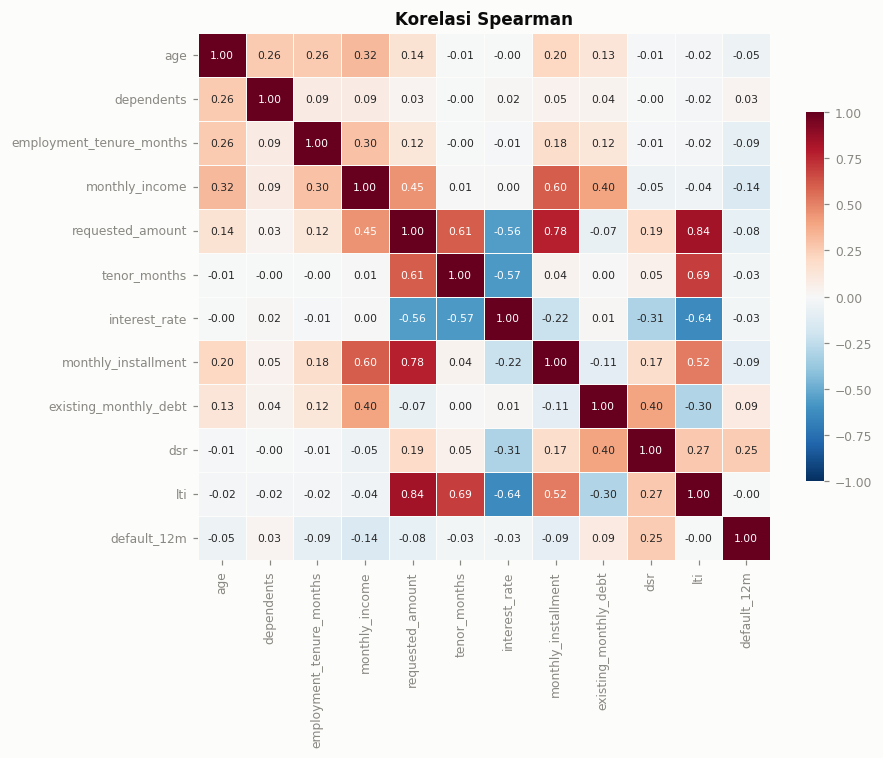

In [18]:
corr_cols = ["age", "dependents", "employment_tenure_months", "monthly_income", "requested_amount", "tenor_months",
             "interest_rate", "monthly_installment", "existing_monthly_debt", "dsr", "lti", "default_12m"]
corr = eda[corr_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 7},
            linewidths=.5, linecolor="#fcfcfb", cbar_kws={"shrink": .7}, ax=ax)
ax.set_title("Korelasi Spearman")
plt.tight_layout()
plt.show()

### 4.6 Early Warning: perilaku bulanan vs label deteriorasi

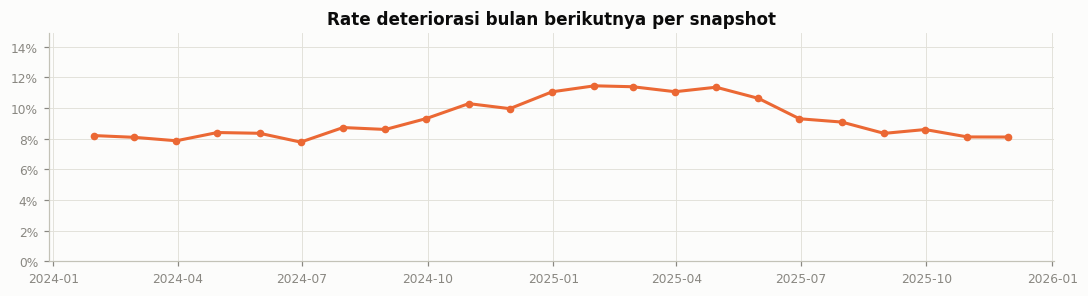

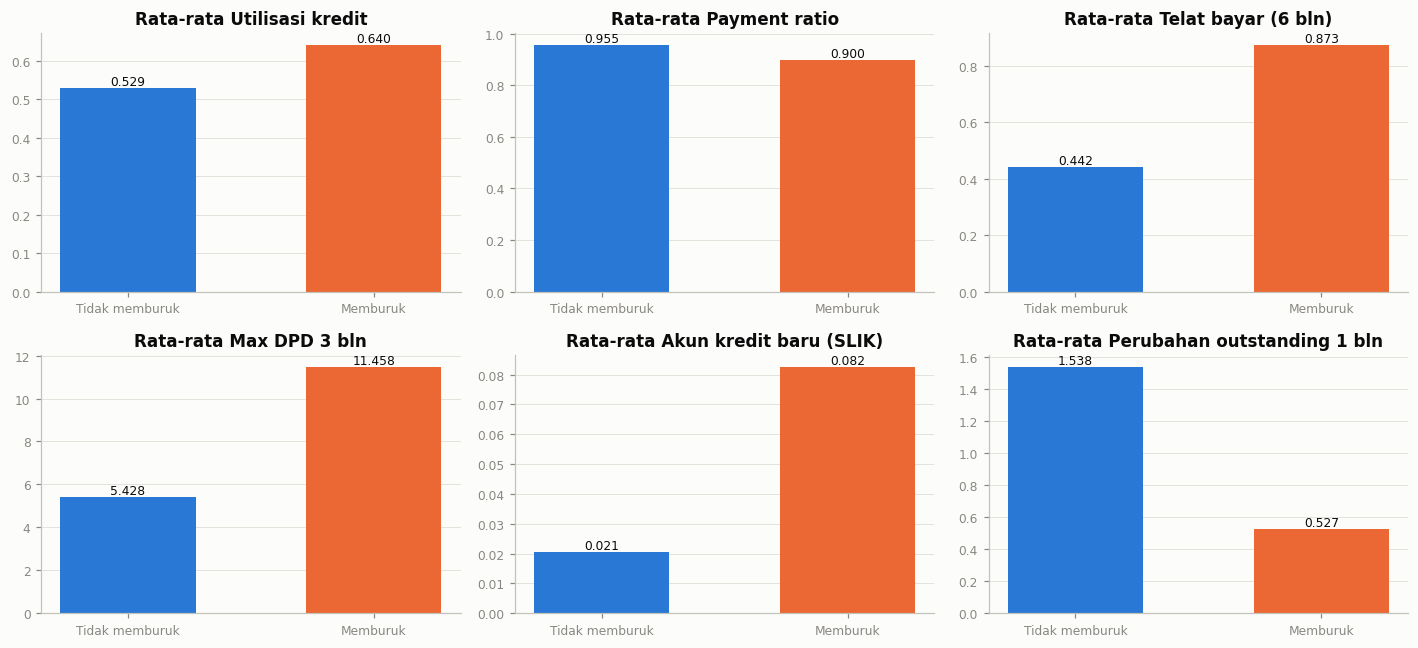

In [19]:
ew = ew_base.dropna(subset=["deterioration_next_1m"])
rate_m = ew.groupby("snapshot_date").deterioration_next_1m.mean()
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.plot(rate_m.index, rate_m.values, color=C_BAD, lw=2, marker="o", ms=4)
ax.set_title("Rate deteriorasi bulan berikutnya per snapshot")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylim(0, rate_m.max() * 1.3)
plt.tight_layout()
plt.show()

feats = [("credit_utilization", "Utilisasi kredit"), ("payment_ratio", "Payment ratio"),
         ("late_payment_count", "Telat bayar (6 bln)"), ("max_dpd_3m", "Max DPD 3 bln"),
         ("new_credit_accounts", "Akun kredit baru (SLIK)"), ("outstanding_change_1m", "Perubahan outstanding 1 bln")]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, (c, label) in zip(axes.ravel(), feats):
    g = ew.groupby("deterioration_next_1m")[c]
    means = g.mean()
    ax.bar(["Tidak memburuk", "Memburuk"], means.values, color=[C_GOOD, C_BAD], width=.55)
    for x, v in enumerate(means.values):
        ax.text(x, v, f"{v:,.3f}", ha="center", va="bottom", fontsize=8, color=INK)
    ax.set_title(f"Rata-rata {label}")
    ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

### 4.7 Jejak perilaku menjelang default (event-time)
Untuk nasabah existing yang default, bulan-bulannya disejajarkan terhadap bulan pertama DPD ≥ 90 (bulan 0).
Grafik ini menunjukkan **berapa bulan sebelumnya sinyal sudah terlihat**, dasar logika Early Warning.

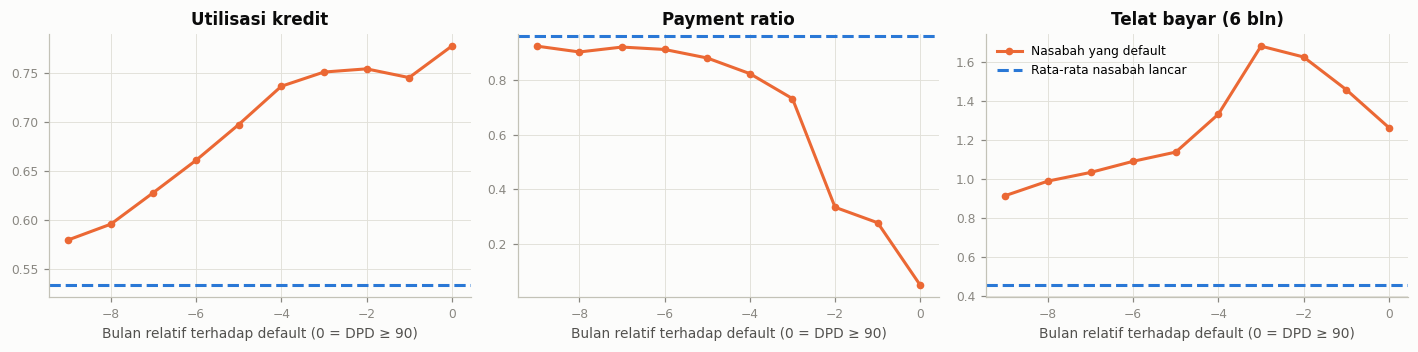

Nasabah existing yang pernah default: 699 dari 8,000


In [20]:
first_def = mb[mb.dpd >= 90].groupby("customer_id").snapshot_date.min().rename("def_date")
et = mb.merge(first_def, on="customer_id")
et["rel_month"] = ((et.snapshot_date.dt.year - et.def_date.dt.year) * 12
                   + et.snapshot_date.dt.month - et.def_date.dt.month)
et = et[et.rel_month.between(-9, 0)]
ref = mb[~mb.customer_id.isin(first_def.index)]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
for ax, (c, label) in zip(axes, [("credit_utilization", "Utilisasi kredit"), ("payment_ratio", "Payment ratio"),
                                 ("late_payment_count", "Telat bayar (6 bln)")]):
    m = et.groupby("rel_month")[c].mean()
    ax.plot(m.index, m.values, color=C_BAD, lw=2, marker="o", ms=4, label="Nasabah yang default")
    ax.axhline(ref[c].mean(), color=C_GOOD, lw=2, ls="--", label="Rata-rata nasabah lancar")
    ax.set_title(label)
    ax.set_xlabel("Bulan relatif terhadap default (0 = DPD ≥ 90)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()
print(f"Nasabah existing yang pernah default: {len(first_def):,} dari {mb.customer_id.nunique():,}")

## 5. Ringkasan insight (dihitung otomatis dari data)

In [21]:
def rate(df, mask):
    return df.loc[mask, "default_12m"].mean()


dsr_hi, dsr_lo = eda.dsr.quantile(.9), eda.dsr.quantile(.1)
lines = [
    f"Default rate Credit Risk: {eda.default_12m.mean():.1%} (new {rate(eda, eda.customer_status == 'new'):.1%}, "
    f"existing {rate(eda, eda.customer_status == 'existing'):.1%}). Rate deteriorasi EW: {ew.deterioration_next_1m.mean():.1%}.",
    f"DSR adalah pendorong terkuat: 10% DSR tertinggi (> {dsr_hi:.2f}) default {rate(eda, eda.dsr > dsr_hi):.1%}, "
    f"10% terendah (< {dsr_lo:.2f}) hanya {rate(eda, eda.dsr < dsr_lo):.1%}.",
    f"Pekerja kontrak default {rate(eda, eda.employment_type == 'Contract'):.1%}, "
    f"karyawan tetap {rate(eda, eda.employment_type == 'Salaried'):.1%}.",
    f"Masa kerja < 12 bulan: {rate(eda, eda.employment_tenure_months < 12):.1%}, "
    f"≥ 12 bulan: {rate(eda, eda.employment_tenure_months >= 12):.1%}.",
    f"Interview: stabilitas penghasilan 'low' default {rate(new, new.income_stability == 'low'):.1%}, "
    f"'high' {rate(new, new.income_stability == 'high'):.1%}. Sering telat bayar: "
    f"{rate(new, new.repayment_issue == 'frequent'):.1%} vs tidak pernah {rate(new, new.repayment_issue == 'none'):.1%}.",
    "Atribut sensitif (gender: " + ", ".join(f"{k} {v:.1%}" for k, v in eda.groupby('gender').default_12m.mean().items())
    + ") tidak berbeda berarti, jadi aman dikeluarkan dari fitur.",
    f"EW: nasabah yang akan memburuk rata-rata utilisasinya {ew.loc[ew.deterioration_next_1m == 1, 'credit_utilization'].mean():.2f} "
    f"vs {ew.loc[ew.deterioration_next_1m == 0, 'credit_utilization'].mean():.2f}, payment ratio "
    f"{ew.loc[ew.deterioration_next_1m == 1, 'payment_ratio'].mean():.2f} vs {ew.loc[ew.deterioration_next_1m == 0, 'payment_ratio'].mean():.2f}.",
    "Sinyal sebelum default (utilisasi naik, payment ratio turun, telat bayar bertambah) mulai terlihat beberapa bulan sebelumnya, "
    "jadi fitur tren/delta di section 6–7 penting untuk Early Warning.",
]
for i, l in enumerate(lines, 1):
    print(f"{i}. {l}")

1. Default rate Credit Risk: 9.7% (new 11.8%, existing 8.7%). Rate deteriorasi EW: 9.3%.
2. DSR adalah pendorong terkuat: 10% DSR tertinggi (> 0.65) default 31.8%, 10% terendah (< 0.25) hanya 1.8%.
3. Pekerja kontrak default 24.9%, karyawan tetap 7.4%.
4. Masa kerja < 12 bulan: 16.8%, ≥ 12 bulan: 9.1%.
5. Interview: stabilitas penghasilan 'low' default 36.5%, 'high' 5.1%. Sering telat bayar: 30.5% vs tidak pernah 6.9%.
6. Atribut sensitif (gender: Female 10.0%, Male 9.5%) tidak berbeda berarti, jadi aman dikeluarkan dari fitur.
7. EW: nasabah yang akan memburuk rata-rata utilisasinya 0.64 vs 0.53, payment ratio 0.90 vs 0.95.
8. Sinyal sebelum default (utilisasi naik, payment ratio turun, telat bayar bertambah) mulai terlihat beberapa bulan sebelumnya, jadi fitur tren/delta di section 6–7 penting untuk Early Warning.


## 6. Feature Engineering
Section 6–7 menyiapkan data untuk **tiga model** dan **dua set fitur** per model:

| Task | Unit | Baseline (fitur mentah) | Feature Engineering (FE) |
|---|---|---|---|
| `cr_new` | aplikasi new applicant | profil + aplikasi + label interview apa adanya | + rasio kemampuan bayar, encoding ordinal interview, sinyal negatif, cek konsistensi hutang |
| `cr_existing` | aplikasi existing customer | profil + aplikasi + snapshot bulanan terakhir sebelum aplikasi | + rasio + agregat perilaku 6 bulan (tren, min/max, akun saat aplikasi) |
| `ew` | nasabah-bulan | kolom bulanan apa adanya | + delta/tren 1–3 bulan, streak, rasio tunggakan, profil statis |

**Aturan anti-leakage:**
- Fitur perilaku Credit Risk existing hanya dari snapshot `snapshot_date < application_date`.
- Status akhir akun (`account_status`, `days_past_due`) tidak dipakai, karena itu hasil.
- Fitur EW hanya memakai informasi sampai bulan t.
- Split dilakukan **sebelum** feature selection. Selection hanya melihat data train.
- EW di-split **per nasabah**, sehingga nasabah yang sama tidak ada di train dan test sekaligus.

**Kebijakan fairness:** `gender`, `city`, `marital_status` tidak dipakai di set fitur mana pun.

In [22]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit

RANDOM_STATE = 42
TEST_SIZE = 0.2
SENSITIVE = ["gender", "city", "marital_status"]
cr = cr_base.copy()          # dari section 3 (in-memory)
print(cr.shape, mb.shape, ac.shape, ew_base.shape)

(12000, 31) (192000, 20) (21990, 13) (192000, 29)


### 6.1 Fitur aplikasi (dipakai new & existing)
| Fitur | Arti bisnis |
|---|---|
| `dsr` | (cicilan baru + cicilan existing) / penghasilan. Rasio utama kemampuan bayar |
| `installment_to_income`, `existing_debt_to_income` | DSR dipecah: beban pinjaman baru vs hutang lama |
| `residual_income`, `residual_income_per_capita` | Sisa penghasilan setelah cicilan, per anggota keluarga |
| `lti` | Plafon / penghasilan setahun |
| `log_income`, `log_amount` | Mengurangi skew (penting untuk Logistic Regression) |
| `short_tenure`, `young_borrower`, `has_business_income`, `secured_loan` | Flag risiko sederhana |

In [23]:
def add_application_features(df):
    d = df.copy()
    inc = d.monthly_income
    d["dsr"] = (d.monthly_installment + d.existing_monthly_debt) / inc
    d["installment_to_income"] = d.monthly_installment / inc
    d["existing_debt_to_income"] = d.existing_monthly_debt / inc
    d["residual_income"] = inc - d.monthly_installment - d.existing_monthly_debt
    d["residual_income_per_capita"] = d.residual_income / (1 + d.dependents)
    d["lti"] = d.requested_amount / (inc * 12)
    d["log_income"] = np.log(inc)
    d["log_amount"] = np.log(d.requested_amount)
    d["tenor_years"] = d.tenor_months / 12
    d["short_tenure"] = (d.employment_tenure_months < 12).astype(int)
    d["young_borrower"] = (d.age < 25).astype(int)
    d["has_business_income"] = (d.income_source != "Salary").astype(int)
    d["secured_loan"] = d.loan_type.isin(["Home Loan", "Auto Loan"]).astype(int)
    return d


cr = add_application_features(cr)
display(cr[["dsr", "installment_to_income", "existing_debt_to_income", "residual_income", "lti"]].describe().T)

,count,mean,std,min,25%,50%,75%,max
dsr,"12,000.0000",0.4511,0.1613,0.0669,0.3381,0.4415,0.5560,1.6712
installment_to_income,"12,000.0000",0.2792,0.1504,0.0027,0.1657,0.2667,0.3784,0.8442
existing_debt_to_income,"12,000.0000",0.1719,0.1782,0.0000,0.0423,0.1119,0.2489,1.6414
residual_income,"12,000.0000","7,317,827.1667","6,423,239.8918","-16,674,000.0000","3,662,750.0000","5,761,000.0000","8,950,000.0000","147,048,000.0000"
lti,"12,000.0000",0.8978,1.0316,0.0035,0.2967,0.5084,1.0334,6.8753


### 6.2 Fitur interview (new applicant)
Label interview diubah jadi fitur yang bisa dipakai model:
- **ordinal** untuk variabel bertingkat (stabilitas, level hutang, masalah bayar);
- **one-hot** untuk variabel nominal (tren, perubahan keuangan, kondisi usaha);
- `interview_neg_signals`: jumlah jawaban yang mengarah ke risiko (0–6);
- `debt_underreported`: hutang yang diakui di interview lebih rendah dari data aplikasi/SLIK.
  Ini sinyal kejujuran yang nanti juga dipakai Agentic AI.

Saat produksi, label-label ini diisi oleh **GenAI** dari jawaban bebas pemohon (notebook GenAI).

In [24]:
IV_LABELS = ["income_trend", "income_stability", "existing_debt_level", "repayment_issue",
             "financial_change", "business_condition"]
ORD = {"income_stability": {"high": 0, "medium": 1, "low": 2},
       "existing_debt_level": {"none": 0, "low": 1, "medium": 2, "high": 3},
       "repayment_issue": {"none": 0, "occasional": 1, "frequent": 2}}


def add_interview_features(df):
    d = df.copy()
    for c, m in ORD.items():
        d[c + "_ord"] = d[c].map(m)
    d["interview_neg_signals"] = (
        d.income_trend.isin(["declining", "volatile"]).astype(int) + (d.income_stability == "low").astype(int)
        + (d.existing_debt_level == "high").astype(int) + (d.repayment_issue != "none").astype(int)
        + (d.financial_change != "stable").astype(int) + (d.business_condition == "declining").astype(int))
    actual = np.select([d.existing_debt_to_income == 0, d.existing_debt_to_income < .12,
                        d.existing_debt_to_income < .25], [0, 1, 2], 3)
    d["debt_underreported"] = (actual > d.existing_debt_level_ord).astype(int)
    return d


cr_new = add_interview_features(cr[cr.customer_status == "new"]).reset_index(drop=True)
print(cr_new.groupby("interview_neg_signals").default_12m.agg(["mean", "count"]))
print(cr_new.groupby("debt_underreported").default_12m.agg(["mean", "count"]))

                        mean  count
interview_neg_signals              
0                     0.0445   1326
1                     0.0742    944
2                     0.1071    700
3                     0.1690    503
4                     0.2966    354
5                     0.4000    135
6                     0.5789     38
                     mean  count
debt_underreported              
0                  0.1159   3597
1                  0.1315    403


### 6.3 Fitur perilaku sebelum aplikasi (existing customer, point-in-time)
Diambil dari **6 snapshot terakhir sebelum `application_date`**, ditambah akun yang sudah aktif saat aplikasi.

In [25]:
def slope(s):
    y = s.to_numpy(dtype=float)
    return float(np.polyfit(np.arange(len(y)), y, 1)[0]) if len(y) > 1 else 0.0


def behaviour_features(apps, monthly, accounts, window=6):
    key = apps[["application_id", "customer_id", "application_date"]]
    m = monthly.merge(key, on="customer_id")
    m = m[m.snapshot_date < m.application_date].sort_values(["application_id", "snapshot_date"])
    m = m.groupby("application_id").tail(window)
    g = m.groupby("application_id")
    f = pd.DataFrame({
        "beh_util_last": g.credit_utilization.last(),
        "beh_util_mean6": g.credit_utilization.mean(),
        "beh_util_trend6": g.credit_utilization.apply(slope),
        "beh_pr_last": g.payment_ratio.last(),
        "beh_pr_mean6": g.payment_ratio.mean(),
        "beh_pr_min6": g.payment_ratio.min(),
        "beh_dpd_last": g.dpd.last(),
        "beh_dpd_max6": g.dpd.max(),
        "beh_months_late6": g.dpd.apply(lambda s: int((s > 0).sum())),
        "beh_late_6m": g.late_payment_count.last(),
        "beh_miss_6m": g.missed_payment_count.last(),
        "beh_newacc_6m": g.new_credit_accounts.sum(),
        "beh_outstanding_growth6": g.total_outstanding.apply(lambda s: s.iloc[-1] / s.iloc[0] - 1 if s.iloc[0] > 0 else 0),
        "beh_overdue_to_due": g.overdue_amount.last() / g.total_amount_due.last().clip(lower=1),
        "beh_due_last": g.total_amount_due.last(),
    })
    # akun yang aktif per tanggal aplikasi (open_date & close_date diketahui saat itu)
    a = accounts.drop(columns="application_id").merge(key, on="customer_id")
    a = a[(a.open_date < a.application_date) & (a.close_date.isna() | (a.close_date > a.application_date))]
    ga = a.groupby("application_id")
    f["acc_active_at_app"] = ga.size()
    f["acc_cards_at_app"] = ga.product_type.apply(lambda s: int((s == "Credit Card").sum()))
    f["acc_limit_at_app"] = ga.credit_limit.sum()
    return f.fillna({"acc_active_at_app": 0, "acc_cards_at_app": 0, "acc_limit_at_app": 0})


def last_snapshot(apps, monthly):
    """Baseline: snapshot mentah terakhir sebelum aplikasi."""
    key = apps[["application_id", "customer_id", "application_date"]]
    m = monthly.merge(key, on="customer_id")
    m = m[m.snapshot_date < m.application_date].sort_values("snapshot_date").groupby("application_id").tail(1)
    cols = ["credit_utilization", "payment_ratio", "dpd", "late_payment_count", "missed_payment_count",
            "overdue_amount", "total_outstanding", "active_accounts", "new_credit_accounts", "max_dpd_3m",
            "avg_utilization_3m"]
    return m.set_index("application_id")[cols].add_prefix("snap_")


cr_ex = cr[cr.customer_status == "existing"].reset_index(drop=True)
beh = behaviour_features(cr_ex, mb, ac)
snap = last_snapshot(cr_ex, mb)
cr_ex = cr_ex.join(beh, on="application_id").join(snap, on="application_id")
cr_ex["months_on_book"] = (cr_ex.application_date - cr_ex.customer_since).dt.days / 30.44
guard("ML", "Process", "fitur perilaku existing lengkap (tanpa NaN)",
      bool(cr_ex[beh.columns.tolist() + snap.columns.tolist()].notna().all().all()))
_k = cr_ex[["application_id", "customer_id", "application_date"]].merge(mb[["customer_id", "snapshot_date"]], on="customer_id")
_used = _k[_k.snapshot_date < _k.application_date].groupby("application_id").snapshot_date.max()
guard("ML", "Process", "point-in-time: snapshot terakhir yang dipakai < tanggal aplikasi",
      bool((_used.reindex(cr_ex.application_id).to_numpy() < cr_ex.application_date.to_numpy()).all()),
      f"jeda median {(cr_ex.application_date - _used.reindex(cr_ex.application_id).to_numpy()).dt.days.median():.0f} hari")
print(cr_ex.shape)
display(cr_ex.groupby("default_12m")[["beh_util_mean6", "beh_util_trend6", "beh_pr_min6", "beh_dpd_max6",
                                      "beh_newacc_6m"]].mean().T)

✅ [ML·Process] fitur perilaku existing lengkap (tanpa NaN)
✅ [ML·Process] point-in-time: snapshot terakhir yang dipakai < tanggal aplikasi — jeda median 16 hari
(8000, 74)


default_12m,0,1
beh_util_mean6,0.3687,0.5224
beh_util_trend6,-0.0062,-0.0081
beh_pr_min6,0.8110,0.6878
beh_dpd_max6,8.3427,15.1159
beh_newacc_6m,0.1234,0.2890


### 6.4 Fitur Early Warning (per nasabah-bulan)
Semua fitur dihitung per nasabah, berurutan waktu, hanya memakai data sampai bulan t.

In [26]:
def ew_features(df):
    d = df.sort_values(["customer_id", "snapshot_date"]).reset_index(drop=True).copy()
    cid = d.customer_id
    g = d.groupby(cid)
    roll = lambda col, w, fn: g[col].transform(lambda s: getattr(s.rolling(w, 1), fn)())
    d["util_delta_1m"] = g.credit_utilization.diff().fillna(0)
    d["util_delta_3m"] = (d.credit_utilization - g.credit_utilization.shift(3)).fillna(d.util_delta_1m)
    d["util_vs_mean6"] = d.credit_utilization - roll("credit_utilization", 6, "mean")
    d["pr_mean_3m"] = roll("payment_ratio", 3, "mean")
    d["pr_min_3m"] = roll("payment_ratio", 3, "min")
    d["pr_delta_3m"] = (d.payment_ratio - g.payment_ratio.shift(3)).fillna(0)
    d["dpd_lag1"] = g.dpd.shift(1).fillna(0)
    d["dpd_delta_1m"] = d.dpd - d.dpd_lag1
    d["late_count_delta"] = g.late_payment_count.diff().fillna(0)
    d["miss_count_delta"] = g.missed_payment_count.diff().fillna(0)
    d["late_now"] = ((d.dpd > 0) & (d.dpd < 30)).astype(int)
    d["in_arrears"] = (d.dpd >= 30).astype(int)
    # bulan sejak terakhir DPD > 0 (24 = belum pernah)
    flag = d.dpd > 0
    grp = flag.astype(int).groupby(cid).cumsum()
    d["months_since_late"] = d.groupby([cid, grp]).cumcount().where(grp > 0, 24).clip(upper=24)
    # berapa bulan berturut-turut payment ratio turun
    dec = g.payment_ratio.diff().fillna(0) < 0
    key = (~dec).astype(int).groupby(cid).cumsum()
    d["pr_decline_streak"] = dec.astype(int).groupby([cid, key]).cumsum()
    d["overdue_to_due"] = d.overdue_amount / d.total_amount_due.clip(lower=1)
    d["payment_gap_to_income"] = (d.total_amount_due - d.total_monthly_payment).clip(lower=0) / d.monthly_income
    d["due_to_income"] = d.total_amount_due / d.monthly_income
    d["outstanding_change_3m"] = (d.total_outstanding / g.total_outstanding.shift(3) - 1).replace([np.inf, -np.inf], 0).fillna(0)
    d["newacc_3m"] = roll("new_credit_accounts", 3, "sum")
    d["newacc_6m"] = roll("new_credit_accounts", 6, "sum")
    d["log_income"] = np.log(d.monthly_income)
    d["months_on_book"] = (d.snapshot_date - d.customer_since).dt.days / 30.44
    return d


ew = ew_features(ew_base)
ew = ew.dropna(subset=["deterioration_next_1m"]).reset_index(drop=True)
ew["deterioration_next_1m"] = ew.deterioration_next_1m.astype(int)
print(ew.shape)
display(ew.groupby("deterioration_next_1m")[["util_delta_3m", "pr_min_3m", "pr_decline_streak",
                                             "months_since_late", "overdue_to_due", "newacc_3m"]].mean().T)

(178717, 51)


deterioration_next_1m,0,1
util_delta_3m,0.0197,0.0275
pr_min_3m,0.8773,0.7712
pr_decline_streak,0.7021,0.7931
months_since_late,14.5388,9.4263
overdue_to_due,0.0755,0.1710
newacc_3m,0.0595,0.1876


## 7. Set fitur, split & feature selection
### 7.1 Definisi set fitur: baseline vs FE

In [27]:
APP_NUM = ["age", "dependents", "employment_tenure_months", "monthly_income", "requested_amount", "tenor_months",
           "interest_rate", "monthly_installment", "existing_monthly_debt"]
APP_CAT = ["employment_type", "income_source", "customer_segment", "loan_type", "loan_purpose", "application_channel"]
APP_FE = ["dsr", "installment_to_income", "existing_debt_to_income", "residual_income", "residual_income_per_capita",
          "lti", "log_income", "log_amount", "tenor_years", "short_tenure", "young_borrower", "has_business_income",
          "secured_loan"]
IV_FE = [c + "_ord" for c in ORD] + ["interview_neg_signals", "debt_underreported"]
IV_NOM = ["income_trend", "financial_change", "business_condition"]
BEH_FE = beh.columns.tolist() + ["months_on_book"]
SNAP = snap.columns.tolist()
EW_RAW = ["total_outstanding", "total_credit_limit", "credit_utilization", "total_monthly_payment", "total_amount_due",
          "payment_ratio", "dpd", "late_payment_count", "missed_payment_count", "overdue_amount", "active_accounts",
          "new_credit_accounts", "outstanding_change_1m", "payment_ratio_change_1m", "max_dpd_3m", "avg_utilization_3m"]
EW_FE = ["util_delta_1m", "util_delta_3m", "util_vs_mean6", "pr_mean_3m", "pr_min_3m", "pr_delta_3m", "dpd_lag1",
         "dpd_delta_1m", "late_count_delta", "miss_count_delta", "late_now", "in_arrears", "months_since_late",
         "pr_decline_streak", "overdue_to_due", "payment_gap_to_income", "due_to_income", "outstanding_change_3m",
         "newacc_3m", "newacc_6m", "log_income", "months_on_book", "age", "employment_tenure_months"]
EW_CAT = ["employment_type", "income_source"]

TASKS = {
    "cr_new": dict(df=cr_new, label="default_12m", group=None,
                   baseline=(APP_NUM + APP_CAT + IV_LABELS, APP_CAT + IV_LABELS),
                   fe=(APP_NUM + APP_CAT + APP_FE + IV_FE + IV_NOM, APP_CAT + IV_NOM),
                   meta=["application_id", "customer_id", "customer_status", "loan_type", "requested_amount",
                         "interest_rate", "tenor_months", "gender", "city"]),
    "cr_existing": dict(df=cr_ex, label="default_12m", group=None,
                        baseline=(APP_NUM + APP_CAT + SNAP, APP_CAT),
                        fe=(APP_NUM + APP_CAT + APP_FE + BEH_FE + SNAP, APP_CAT),
                        meta=["application_id", "customer_id", "customer_status", "loan_type", "requested_amount",
                              "interest_rate", "tenor_months", "gender", "city"]),
    "ew": dict(df=ew, label="deterioration_next_1m", group="customer_id",
               baseline=(EW_RAW, []),
               fe=(EW_RAW + EW_FE + EW_CAT, EW_CAT),
               meta=["customer_id", "snapshot_date", "total_outstanding", "default_next_3m", "gender", "city"]),
}
for t, cfg in TASKS.items():
    for fs in ("baseline", "fe"):
        cols = list(dict.fromkeys(cfg[fs][0]))
        guard("ML", "Process", f"{t}/{fs}: tanpa atribut sensitif", not set(cols) & set(SENSITIVE), quiet=True)
        cfg[fs] = (cols, cfg[fs][1])
    print(f"{t:12s} baseline={len(cfg['baseline'][0]):3d} kolom | FE (sebelum seleksi)={len(cfg['fe'][0]):3d} kolom")

cr_new       baseline= 21 kolom | FE (sebelum seleksi)= 36 kolom
cr_existing  baseline= 26 kolom | FE (sebelum seleksi)= 58 kolom
ew           baseline= 16 kolom | FE (sebelum seleksi)= 42 kolom


### 7.2 Split train/test + Process Guardrail
- Credit Risk: stratified 80/20 (satu aplikasi per nasabah).
- EW: 80/20 **per nasabah** (GroupShuffleSplit).

In [28]:
splits = {}
for t, cfg in TASKS.items():
    df, y = cfg["df"], cfg["df"][cfg["label"]]
    if cfg["group"] is None:
        tr_idx, te_idx = train_test_split(np.arange(len(df)), test_size=TEST_SIZE, stratify=y,
                                          random_state=RANDOM_STATE)
    else:
        tr_idx, te_idx = next(GroupShuffleSplit(1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
                              .split(df, y, groups=df[cfg["group"]]))
    splits[t] = (np.sort(tr_idx), np.sort(te_idx))
    print(f"{t:12s} train={len(tr_idx):6,} (pos {y.iloc[tr_idx].mean():.1%}) | "
          f"test={len(te_idx):6,} (pos {y.iloc[te_idx].mean():.1%})")
if TASKS["ew"]["group"]:
    df = TASKS["ew"]["df"]
    tr, te = splits["ew"]
    guard("ML", "Process", "EW: nasabah train & test tidak beririsan",
          not set(df.customer_id.iloc[tr]) & set(df.customer_id.iloc[te]))
for t, (tr, te) in splits.items():
    yy = TASKS[t]["df"][TASKS[t]["label"]]
    gap = abs(yy.iloc[tr].mean() - yy.iloc[te].mean())
    guard("ML", "Process", f"{t}: rate positif train ≈ test", gap < 0.02, f"selisih {gap:.3f}", severity="warn")

cr_new       train= 3,200 (pos 11.8%) | test=   800 (pos 11.8%)
cr_existing  train= 6,400 (pos 8.7%) | test= 1,600 (pos 8.8%)
ew           train=142,842 (pos 9.3%) | test=35,875 (pos 9.4%)
✅ [ML·Process] EW: nasabah train & test tidak beririsan
✅ [ML·Process] cr_new: rate positif train ≈ test — selisih 0.000
✅ [ML·Process] cr_existing: rate positif train ≈ test — selisih 0.000
✅ [ML·Process] ew: rate positif train ≈ test — selisih 0.001


### 7.3 Feature selection (hanya pada set FE, hanya memakai data train)
Tiga langkah:
1. **Near-constant**: buang fitur yang ≥ 99% nilainya sama.
2. **Information Value (IV)**: standar industri credit scoring. Buang fitur dengan IV < 0,02 (tidak prediktif).
   Panduan: 0,02–0,1 lemah · 0,1–0,3 sedang · > 0,3 kuat · > 0,5 dicurigai leakage (dicek manual).
3. **Korelasi**: dari pasangan numerik dengan |Spearman| > 0,85, buang yang IV-nya lebih kecil.

In [29]:
IV_MIN, CORR_MAX, CONST_MAX = 0.02, 0.85, 0.99


def information_value(x, y, bins=10):
    if not pd.api.types.is_numeric_dtype(x) or x.nunique() <= bins:
        b = x.astype(str)
    else:
        b = pd.qcut(x.rank(method="first"), bins, labels=False)
    t = pd.crosstab(b, y)
    good, bad = t.get(0, 0) + .5, t.get(1, 0) + .5
    pg, pb = good / good.sum(), bad / bad.sum()
    return float(((pb - pg) * np.log(pb / pg)).sum())


def select_features(X, y, cats):
    rep = []
    for c in X.columns:
        top = X[c].value_counts(normalize=True, dropna=False).iloc[0]
        rep.append({"feature": c, "iv": information_value(X[c], y), "top_share": top,
                    "type": "cat" if c in cats else "num"})
    rep = pd.DataFrame(rep).set_index("feature")
    rep["status"] = "kept"
    rep.loc[rep.top_share >= CONST_MAX, "status"] = "drop: near-constant"
    rep.loc[(rep.status == "kept") & (rep.iv < IV_MIN), "status"] = "drop: IV < 0.02"
    num = [c for c in rep.index[rep.status == "kept"] if c not in cats]
    corr = X[num].corr(method="spearman").abs()
    for c in rep.loc[num].sort_values("iv", ascending=False).index:
        if rep.at[c, "status"] != "kept":
            continue
        for o in corr.index[(corr[c] > CORR_MAX) & (corr.index != c)]:
            if rep.at[o, "status"] == "kept" and rep.at[o, "iv"] <= rep.at[c, "iv"]:
                rep.at[o, "status"] = f"drop: corr {corr.at[c, o]:.2f} dgn {c}"
    rep["strength"] = pd.cut(rep.iv, [-1, .02, .1, .3, .5, 99], labels=["useless", "weak", "medium", "strong", "suspicious"])
    return rep.sort_values("iv", ascending=False)


reports = {}
for t, cfg in TASKS.items():
    tr, _ = splits[t]
    cols, cats = cfg["fe"]
    rep = select_features(cfg["df"].iloc[tr][cols], cfg["df"][cfg["label"]].iloc[tr], cats)
    reports[t] = rep
    print(f"\n=== {t}: {int((rep.status == 'kept').sum())} dari {len(rep)} fitur dipertahankan ===")
    display(rep[rep.status != "kept"][["iv", "status"]])


=== cr_new: 24 dari 36 fitur dipertahankan ===


,iv,status
feature,,
existing_debt_level_ord,0.3079,drop: corr 0.93 dgn existing_debt_to_income
monthly_income,0.2479,drop: corr 0.90 dgn residual_income
log_income,0.2479,drop: corr 0.90 dgn residual_income
log_amount,0.1744,drop: corr 1.00 dgn requested_amount
existing_monthly_debt,0.0880,drop: corr 0.88 dgn existing_debt_to_income
tenor_years,0.0283,drop: corr 1.00 dgn tenor_months
application_channel,0.0139,drop: IV < 0.02
loan_type,0.0129,drop: IV < 0.02
secured_loan,0.0096,drop: IV < 0.02



=== cr_existing: 34 dari 58 fitur dipertahankan ===


,iv,status
feature,,
beh_util_last,0.4442,drop: corr 0.96 dgn beh_util_mean6
snap_credit_utilization,0.4442,drop: corr 0.96 dgn beh_util_mean6
snap_avg_utilization_3m,0.4322,drop: corr 0.99 dgn beh_util_mean6
beh_pr_last,0.3561,drop: corr 1.00 dgn snap_payment_ratio
snap_late_payment_count,0.3238,drop: corr 0.90 dgn beh_months_late6
beh_late_6m,0.3238,drop: corr 0.90 dgn beh_months_late6
beh_dpd_max6,0.2507,drop: corr 0.97 dgn beh_months_late6
log_income,0.2453,drop: corr 0.86 dgn residual_income
monthly_income,0.2453,drop: corr 0.86 dgn residual_income



=== ew: 25 dari 42 fitur dipertahankan ===


,iv,status
feature,,
payment_gap_to_income,0.3995,drop: corr 0.92 dgn payment_ratio
credit_utilization,0.2166,drop: corr 0.94 dgn avg_utilization_3m
total_amount_due,0.1163,drop: corr 0.88 dgn total_outstanding
total_monthly_payment,0.0826,drop: corr 0.85 dgn total_outstanding
util_delta_3m,0.0398,drop: corr 0.87 dgn util_vs_mean6
overdue_to_due,0.0316,drop: corr 1.00 dgn overdue_amount
dpd,0.0302,drop: corr 1.00 dgn overdue_amount
util_delta_1m,0.0218,drop: corr 0.90 dgn outstanding_change_1m
employment_type,0.0180,drop: IV < 0.02


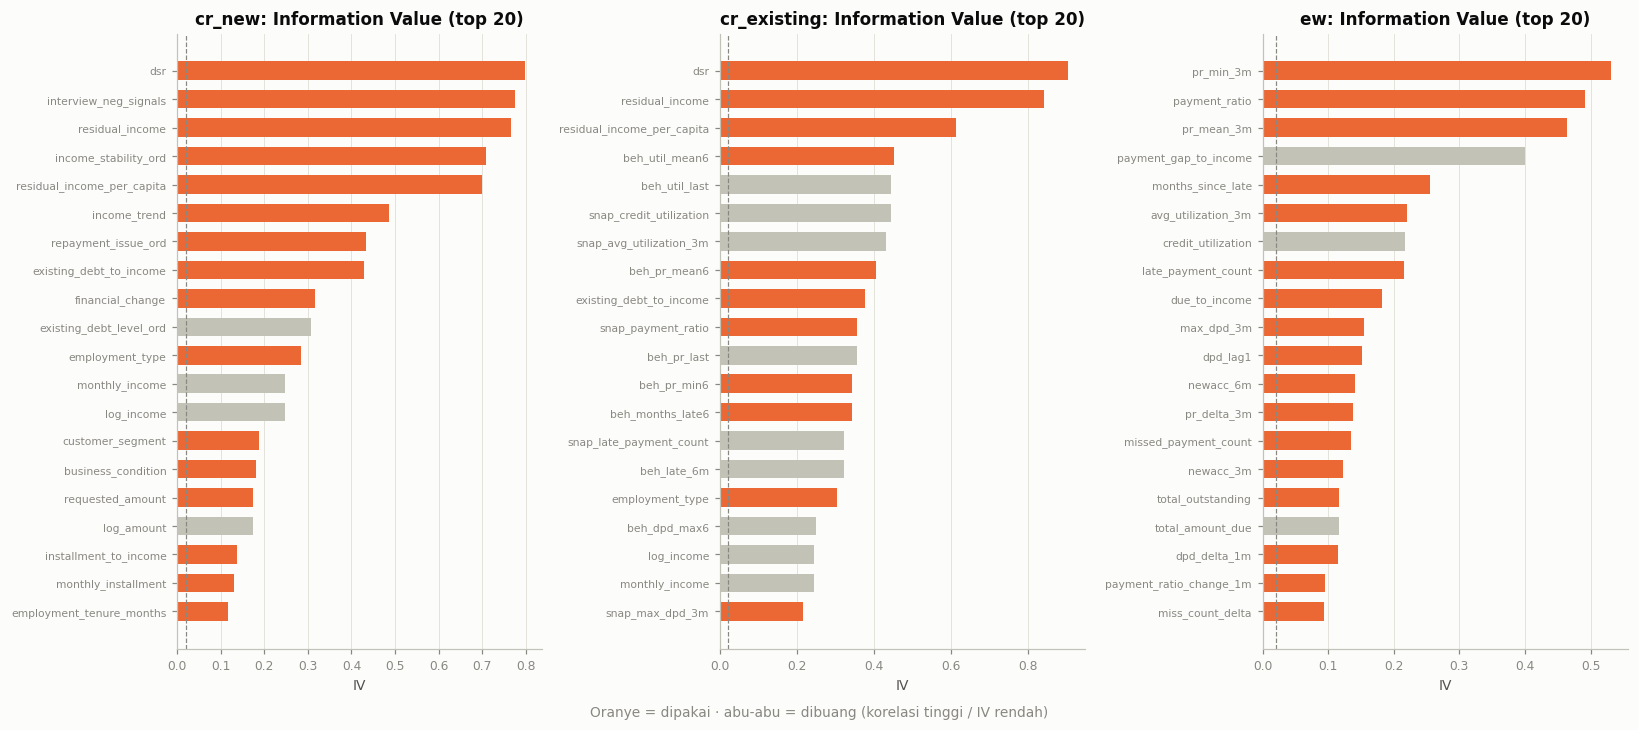

Fitur IV > 0,5 (dicek manual): {'cr_new': ['dsr', 'interview_neg_signals', 'residual_income', 'income_stability_ord', 'residual_income_per_capita'], 'cr_existing': ['dsr', 'residual_income', 'residual_income_per_capita'], 'ew': ['pr_min_3m']}


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6.5))
for ax, (t, rep) in zip(axes, reports.items()):
    top = rep.head(20).iloc[::-1]
    colors = [C_BAD if s == "kept" else "#c3c2b7" for s in top.status]
    ax.barh(top.index, top.iv, color=colors, height=.65)
    ax.axvline(IV_MIN, color=MUTED, ls="--", lw=.8)
    ax.set_title(f"{t}: Information Value (top 20)")
    ax.set_xlabel("IV")
    ax.grid(axis="y", visible=False)
    ax.tick_params(axis="y", labelsize=7)
fig.text(.5, -.01, "Oranye = dipakai · abu-abu = dibuang (korelasi tinggi / IV rendah)", ha="center", color=MUTED, fontsize=9)
plt.tight_layout()
plt.show()
sus = {t: r.index[r.strength == "suspicious"].tolist() for t, r in reports.items()}
print("Fitur IV > 0,5 (dicek manual):", sus)

Fitur dengan IV > 0,5 (misalnya DSR, residual income, stabilitas penghasilan, `pr_min_3m`) sudah dicek dan **bukan leakage**:
semuanya diketahui pada saat prediksi (tanggal aplikasi / bulan t) dan memang pendorong risiko yang kuat secara bisnis.
Label Credit Risk bicara soal 12 bulan setelah pencairan, label EW soal bulan **t+1**.

### 7.4 Encoding dataset model + Process Guardrail (anti-leakage)
One-hot encoding memakai kategori dari data train (kategori baru di test → semua 0).
Scaling untuk Logistic Regression dilakukan di dalam pipeline model (section 8), supaya tidak bocor.

In [31]:
def encode(train, test, cats):
    tr = pd.get_dummies(train, columns=cats, dtype=float)
    te = pd.get_dummies(test, columns=cats, dtype=float).reindex(columns=tr.columns, fill_value=0.0)
    return tr.astype(float), te.astype(float)


datasets = {}
for t, cfg in TASKS.items():
    df, tr, te = cfg["df"], *splits[t]
    out = {"task": t, "label": cfg["label"], "X_train": {}, "X_test": {}, "features": {},
           "y_train": df[cfg["label"]].iloc[tr].to_numpy(), "y_test": df[cfg["label"]].iloc[te].to_numpy(),
           "groups_train": df[cfg["group"]].iloc[tr].to_numpy() if cfg["group"] else None,
           "meta_train": df[cfg["meta"]].iloc[tr].reset_index(drop=True),
           "meta_test": df[cfg["meta"]].iloc[te].reset_index(drop=True),
           "selection_report": reports[t]}
    for fs in ("baseline", "fe"):
        cols, cats = cfg[fs]
        if fs == "fe":
            cols = reports[t].index[reports[t].status == "kept"].tolist()
        cats = [c for c in cats if c in cols]
        Xtr, Xte = encode(df.iloc[tr][cols], df.iloc[te][cols], cats)
        assert not Xtr.isna().any().any() and not Xte.isna().any().any(), f"NaN di {t}/{fs}"
        out["X_train"][fs], out["X_test"][fs] = Xtr.reset_index(drop=True), Xte.reset_index(drop=True)
        out["features"][fs] = {"raw": cols, "encoded": Xtr.columns.tolist(), "categorical": cats}
    datasets[t] = out

summary = pd.DataFrame([{"task": t, "fitur_baseline": d["X_train"]["baseline"].shape[1],
                         "fitur_FE": d["X_train"]["fe"].shape[1], "train": len(d["y_train"]),
                         "test": len(d["y_test"]), "pos_rate_train": d["y_train"].mean()}
                        for t, d in datasets.items()])
display(summary)

# Process Guardrail: tidak boleh ada kolom outcome, ID, atau atribut sensitif di fitur model
FORBIDDEN = {"default_12m", "deterioration_next_1m", "default_next_3m", "account_status", "days_past_due",
             "outstanding", "close_date", "disbursement_date", "customer_id", "application_id", "snapshot_date"}
for t, d in datasets.items():
    for fs in ("baseline", "fe"):
        raw = set(d["features"][fs]["raw"])
        guard("ML", "Process", f"{t}/{fs}: tanpa kolom outcome/ID", not raw & FORBIDDEN, sorted(raw & FORBIDDEN) or "", quiet=True)
        guard("ML", "Process", f"{t}/{fs}: tanpa atribut sensitif", not raw & set(SENSITIVE), quiet=True)
guard("ML", "Process", "feature selection hanya memakai data train", True, "IV & korelasi dihitung di index train")
print("Anti-leakage & fairness (fitur): semua lolos.")

,task,fitur_baseline,fitur_FE,train,test,pos_rate_train
0,cr_new,57,46,3200,800,0.1175
1,cr_existing,46,50,6400,1600,0.0873
2,ew,16,25,142842,35875,0.0929


✅ [ML·Process] feature selection hanya memakai data train — IV & korelasi dihitung di index train
Anti-leakage & fairness (fitur): semua lolos.


## 8. Modelling: baseline vs feature engineering
Tiga algoritma × dua set fitur × tiga task = **18 model**.

| Algoritma | Alasan dipilih |
|---|---|
| **Logistic Regression** | Baseline interpretable, standar regulator untuk credit scoring |
| **Random Forest** | Bagging, tahan outlier, menangkap non-linearitas tanpa banyak tuning |
| **XGBoost** | Boosting, biasanya terbaik untuk data tabular, jalan di GPU A100 |

**Protokol evaluasi (fokus recall):**
1. Tuning hyperparameter dengan `RandomizedSearchCV` (3-fold CV di train; EW pakai GroupKFold per nasabah),
   skor = **PR-AUC**. PR-AUC dipakai karena tidak bergantung threshold dan cocok untuk kelas tidak seimbang.
2. Threshold dipilih dari **prediksi out-of-fold** di train dengan memaksimalkan **F2-score**.
   F2 memberi bobot recall 2× precision, sesuai prioritas: lebih baik salah tolak daripada meloloskan calon default.
3. Test set hanya dipakai sekali di akhir untuk melaporkan Recall, Precision, F1, F2, ROC-AUC, PR-AUC.
4. Model terbaik per task dipilih dari **F2 out-of-fold** (bukan dari test, supaya tidak bias).

Threshold final bisnis diatur interaktif di section 12.

In [32]:
import json, time, subprocess
import numpy as np
import pandas as pd
import joblib
from IPython.display import display
from scipy.stats import loguniform, randint
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, GroupKFold, cross_val_predict
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_recall_curve, recall_score,
                             precision_score, f1_score, fbeta_score, confusion_matrix)
try:
    import xgboost as xgb
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "xgboost"], check=True)
    import xgboost as xgb
from xgboost import XGBClassifier

RANDOM_STATE = 42
FAST_MODE = os.environ.get("ICA_FAST", "0") == "1"      # set True hanya untuk uji cepat
N_ITER = {"cr": 2, "ew": 2} if FAST_MODE else {"cr": 25, "ew": 12}
EW_TUNE_ROWS = 8_000 if FAST_MODE else 60_000            # tuning EW di subsampel nasabah, model final di full train
CV_FOLDS = 3


def has_gpu():
    try:
        return subprocess.run(["nvidia-smi"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


XGB_DEVICE = "cuda" if has_gpu() else "cpu"
N_CPU = os.cpu_count()
print(f"xgboost {xgb.__version__} | device XGBoost: {XGB_DEVICE} | CPU: {N_CPU} | FAST_MODE={FAST_MODE}")

TASK_IDS = ["cr_new", "cr_existing", "ew"]
TASK_NAMES = {"cr_new": "Credit Risk · New", "cr_existing": "Credit Risk · Existing", "ew": "Early Warning"}
DATA = datasets               # dari section 7 (in-memory)
for t in TASK_IDS:
    print(t, {fs: DATA[t]["X_train"][fs].shape for fs in ("baseline", "fe")})

xgboost 3.4.1 | device XGBoost: cuda | CPU: 12 | FAST_MODE=False
cr_new {'baseline': (3200, 57), 'fe': (3200, 46)}
cr_existing {'baseline': (6400, 46), 'fe': (6400, 50)}
ew {'baseline': (142842, 16), 'fe': (142842, 25)}


### 8.1 Definisi model & ruang hyperparameter
- Ketidakseimbangan kelas: `class_weight="balanced"` (LogReg, RF) dan `scale_pos_weight` (XGBoost).
- LogReg memakai `StandardScaler` di dalam pipeline, jadi scaling hanya di-fit pada fold train.

In [33]:
MODELS = ["LogReg", "RandomForest", "XGBoost"]


def make_model(name, pos_weight, task):
    if name == "LogReg":
        return Pipeline([("scaler", StandardScaler()),
                         ("clf", LogisticRegression(max_iter=5000, class_weight="balanced"))])
    if name == "RandomForest":
        return RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample", n_jobs=-1,
                                      max_samples=0.5 if task == "ew" else None, random_state=RANDOM_STATE)
    return XGBClassifier(n_estimators=400, tree_method="hist", device=XGB_DEVICE, scale_pos_weight=pos_weight,
                         eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=N_CPU, verbosity=0)


SPACES = {
    "LogReg": {"clf__C": loguniform(1e-3, 10)},
    "RandomForest": {"n_estimators": [200, 300, 500], "max_depth": [6, 8, 12, 16, None],
                     "min_samples_leaf": [5, 10, 20, 50], "max_features": ["sqrt", 0.3, 0.5]},
    "XGBoost": {"n_estimators": randint(200, 900), "learning_rate": loguniform(0.01, 0.2),
                "max_depth": randint(3, 9), "min_child_weight": [1, 3, 5, 10], "subsample": [0.7, 0.85, 1.0],
                "colsample_bytree": [0.6, 0.8, 1.0], "reg_lambda": loguniform(0.1, 10)},
}
if FAST_MODE:
    SPACES["RandomForest"]["n_estimators"] = [50]
    SPACES["XGBoost"]["n_estimators"] = [100]

### 8.2 Fungsi training & evaluasi

In [34]:
def f2_threshold(y, p):
    prec, rec, thr = precision_recall_curve(y, p)
    f2 = 5 * prec * rec / np.clip(4 * prec + rec, 1e-12, None)
    i = int(np.nanargmax(f2[:-1]))
    return float(thr[i]), float(f2[i])


def metrics_at(y, p, thr):
    yhat = (p >= thr).astype(int)
    return {"roc_auc": roc_auc_score(y, p), "pr_auc": average_precision_score(y, p),
            "recall": recall_score(y, yhat), "precision": precision_score(y, yhat, zero_division=0),
            "f1": f1_score(y, yhat), "f2": fbeta_score(y, yhat, beta=2), "recall@0.5": recall_score(y, p >= .5)}


def run(task, fs, name):
    d = DATA[task]
    Xtr, Xte, ytr, yte = d["X_train"][fs], d["X_test"][fs], d["y_train"], d["y_test"]
    groups = d["groups_train"]
    est = make_model(name, (ytr == 0).sum() / (ytr == 1).sum(), task)
    if groups is None:
        cv = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
        Xs, ys, gs = Xtr, ytr, None
    else:
        cv = GroupKFold(CV_FOLDS)
        rng = np.random.RandomState(RANDOM_STATE)
        cust = np.unique(groups)
        keep = rng.choice(cust, size=min(len(cust), max(1, int(len(cust) * EW_TUNE_ROWS / len(groups)))), replace=False)
        m = np.isin(groups, keep)
        Xs, ys, gs = Xtr[m], ytr[m], groups[m]
    t0 = time.time()
    search = RandomizedSearchCV(est, SPACES[name], n_iter=N_ITER["ew" if task == "ew" else "cr"],
                                scoring="average_precision", cv=cv, random_state=RANDOM_STATE, refit=False,
                                n_jobs=1 if name != "LogReg" else -1)
    search.fit(Xs, ys, groups=gs)
    best = clone(est).set_params(**search.best_params_)
    oof = cross_val_predict(best, Xtr, ytr, cv=cv, groups=groups, method="predict_proba")[:, 1]
    thr, oof_f2 = f2_threshold(ytr, oof)
    best.fit(Xtr, ytr)
    p_test = best.predict_proba(Xte)[:, 1]
    res = {"task": task, "feature_set": fs, "model": name, "n_features": Xtr.shape[1],
           "cv_pr_auc": search.best_score_, "oof_pr_auc": average_precision_score(ytr, oof), "oof_f2": oof_f2,
           "threshold": thr, **{f"test_{k}": v for k, v in metrics_at(yte, p_test, thr).items()},
           "fit_sec": time.time() - t0, "params": json.dumps(search.best_params_, default=str)}
    return res, best, p_test, oof

### 8.3 Jalankan 18 eksperimen
Estimasi waktu di runtime Colab A100: sekitar 15–30 menit (paling lama Random Forest di data EW).

In [35]:
results, fitted, test_preds, OOF = [], {}, {}, {}
for task in TASK_IDS:
    for fs in ("baseline", "fe"):
        for name in MODELS:
            res, model, p, oof = run(task, fs, name)
            OOF[(task, fs, name)] = oof
            results.append(res)
            fitted[(task, fs, name)] = model
            test_preds[(task, fs, name)] = p
            print(f"{task:12s} {fs:8s} {name:12s} | OOF F2 {res['oof_f2']:.3f} | test recall {res['test_recall']:.3f} "
                  f"prec {res['test_precision']:.3f} PR-AUC {res['test_pr_auc']:.3f} | thr {res['threshold']:.3f} "
                  f"| {res['fit_sec']:.0f}s")
R = pd.DataFrame(results)
R.to_csv(ART_DIR / "03_results.csv", index=False)

cr_new       baseline LogReg       | OOF F2 0.554 | test recall 0.532 prec 0.272 PR-AUC 0.379 | thr 0.563 | 2s
cr_new       baseline RandomForest | OOF F2 0.529 | test recall 0.670 prec 0.214 PR-AUC 0.343 | thr 0.329 | 83s
cr_new       baseline XGBoost      | OOF F2 0.534 | test recall 0.628 prec 0.258 PR-AUC 0.349 | thr 0.366 | 64s
cr_new       fe       LogReg       | OOF F2 0.572 | test recall 0.574 prec 0.290 PR-AUC 0.407 | thr 0.536 | 0s
cr_new       fe       RandomForest | OOF F2 0.565 | test recall 0.660 prec 0.313 PR-AUC 0.391 | thr 0.384 | 84s
cr_new       fe       XGBoost      | OOF F2 0.555 | test recall 0.670 prec 0.265 PR-AUC 0.387 | thr 0.462 | 62s
cr_existing  baseline LogReg       | OOF F2 0.486 | test recall 0.664 prec 0.249 PR-AUC 0.310 | thr 0.572 | 1s
cr_existing  baseline RandomForest | OOF F2 0.461 | test recall 0.643 prec 0.205 PR-AUC 0.294 | thr 0.435 | 100s
cr_existing  baseline XGBoost      | OOF F2 0.462 | test recall 0.814 prec 0.175 PR-AUC 0.340 | thr 0.311 

### 8.4 Perbandingan baseline vs feature engineering

,task,feature_set,model,n_features,oof_f2,threshold,test_recall,test_precision,test_f1,test_f2,test_pr_auc,test_roc_auc
0,cr_new,baseline,LogReg,57,0.5540,0.5630,0.5320,0.2720,0.3600,0.4460,0.3790,0.7900
1,cr_new,baseline,RandomForest,57,0.5290,0.3290,0.6700,0.2140,0.3250,0.4700,0.3430,0.7580
2,cr_new,baseline,XGBoost,57,0.5340,0.3660,0.6280,0.2580,0.3650,0.4880,0.3490,0.7790
3,cr_new,fe,LogReg,46,0.5720,0.5360,0.5740,0.2900,0.3860,0.4800,0.4070,0.8090
4,cr_new,fe,RandomForest,46,0.5650,0.3840,0.6600,0.3130,0.4250,0.5400,0.3910,0.8080
5,cr_new,fe,XGBoost,46,0.5550,0.4620,0.6700,0.2650,0.3800,0.5130,0.3870,0.7960
6,cr_existing,baseline,LogReg,46,0.4860,0.5720,0.6640,0.2490,0.3630,0.4980,0.3100,0.7970
7,cr_existing,baseline,RandomForest,46,0.4610,0.4350,0.6430,0.2050,0.3110,0.4510,0.2940,0.7880
8,cr_existing,baseline,XGBoost,46,0.4620,0.3110,0.8140,0.1750,0.2880,0.4700,0.3400,0.7970
9,cr_existing,fe,LogReg,50,0.5160,0.5680,0.6210,0.2590,0.3660,0.4850,0.3440,0.8110


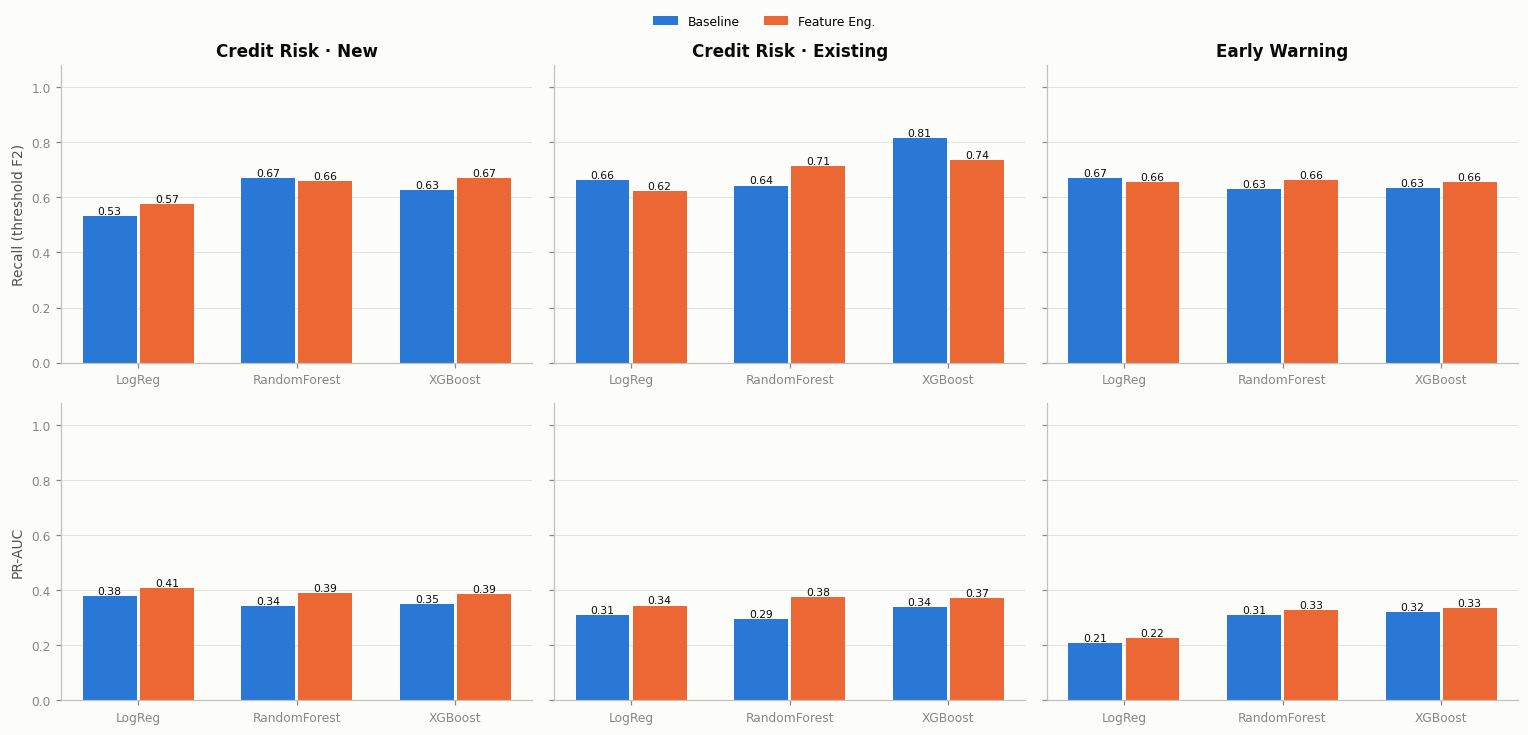

Kenaikan FE dibanding baseline (positif = FE lebih baik):


test_recall  test_f2  test_pr_auc
task        model                                          
cr_existing LogReg            -0.0430  -0.0130       0.0340
            RandomForest       0.0710   0.0490       0.0820
            XGBoost           -0.0790   0.0140       0.0300
cr_new      LogReg             0.0430   0.0340       0.0280
            RandomForest      -0.0110   0.0700       0.0480
            XGBoost            0.0430   0.0250       0.0380
ew          LogReg            -0.0140   0.0080       0.0180
            RandomForest       0.0330   0.0110       0.0170
            XGBoost            0.0220   0.0060       0.0150

In [36]:
show = ["task", "feature_set", "model", "n_features", "oof_f2", "threshold", "test_recall", "test_precision",
        "test_f1", "test_f2", "test_pr_auc", "test_roc_auc"]
display(R[show].round(3))

fig, axes = plt.subplots(2, 3, figsize=(14, 6.5), sharey="row")
for j, task in enumerate(TASK_IDS):
    for i, (metric, label) in enumerate([("test_recall", "Recall (threshold F2)"), ("test_pr_auc", "PR-AUC")]):
        ax = axes[i, j]
        sub = R[R.task == task].pivot(index="model", columns="feature_set", values=metric).reindex(MODELS)
        x = np.arange(len(MODELS))
        for k, fs in enumerate(["baseline", "fe"]):
            bars = ax.bar(x + (k - .5) * .36, sub[fs], width=.34, color=FS_COLORS[fs],
                          label="Baseline" if fs == "baseline" else "Feature Eng.")
            for b, v in zip(bars, sub[fs]):
                ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.2f}", ha="center", va="bottom", fontsize=7, color=INK)
        ax.set_xticks(x)
        ax.set_xticklabels(MODELS)
        ax.set_ylim(0, 1.08)
        ax.grid(axis="x", visible=False)
        if i == 0:
            ax.set_title(TASK_NAMES[task])
        if j == 0:
            ax.set_ylabel(label)
h, l = axes[0, 0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", ncol=2, bbox_to_anchor=(.5, 1.03))
plt.tight_layout()
plt.show()

gain = (R.pivot_table(index=["task", "model"], columns="feature_set", values=["test_recall", "test_pr_auc", "test_f2"])
        .pipe(lambda d: pd.DataFrame({m: d[(m, "fe")] - d[(m, "baseline")] for m in ["test_recall", "test_f2", "test_pr_auc"]})))
print("Kenaikan FE dibanding baseline (positif = FE lebih baik):")
display(gain.round(3))

### 8.5 Pilih model terbaik per task
Kriteria: **F2 out-of-fold tertinggi** (tidak melihat test). Test set hanya untuk konfirmasi.

,feature_set,model,oof_f2,threshold,test_recall,test_precision,test_f2,test_pr_auc
task,,,,,,,,
cr_existing,fe,LogReg,0.5160,0.5680,0.6210,0.2590,0.4850,0.3440
cr_new,fe,LogReg,0.5720,0.5360,0.5740,0.2900,0.4800,0.4070
ew,fe,XGBoost,0.4690,0.5090,0.6560,0.2210,0.4710,0.3340


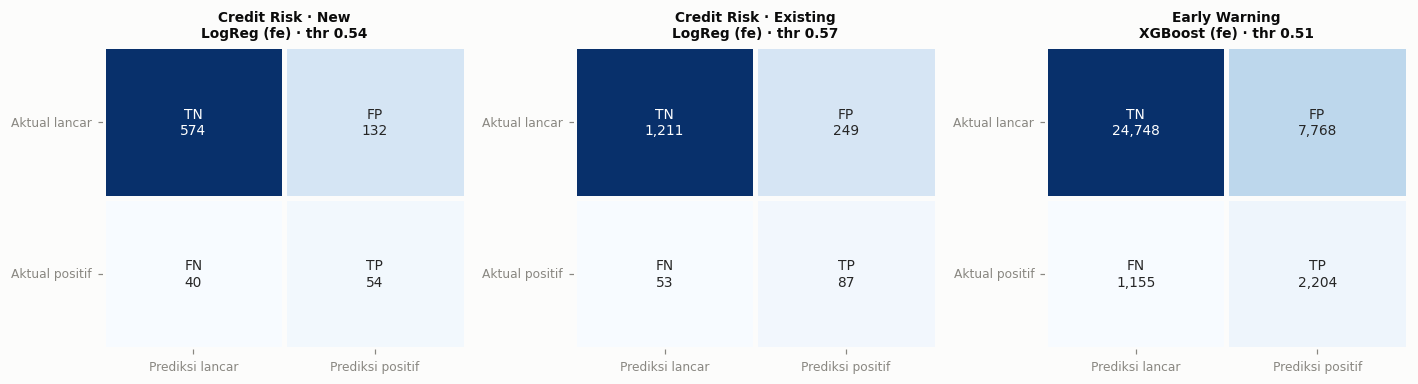

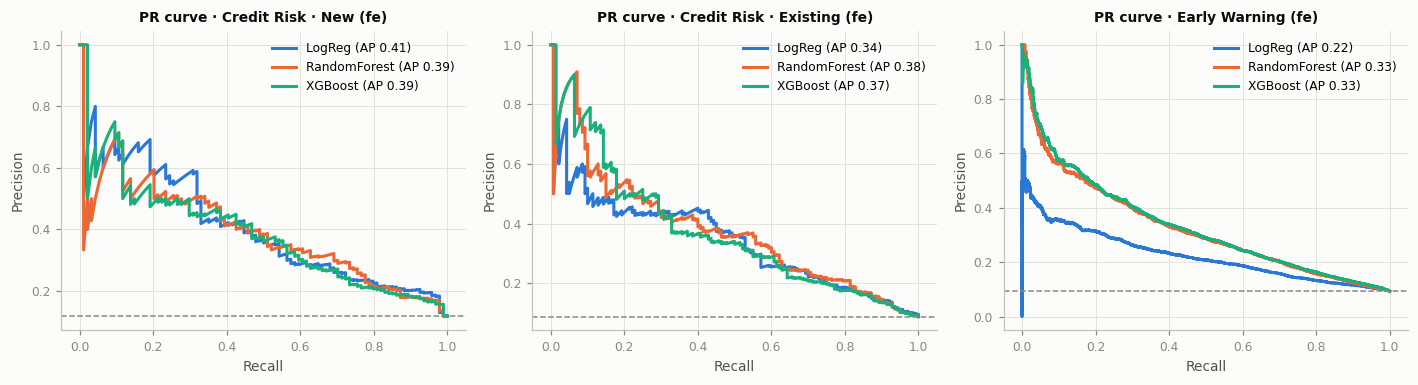

In [37]:
best_rows = R.loc[R.groupby("task").oof_f2.idxmax()].set_index("task")
display(best_rows[["feature_set", "model", "oof_f2", "threshold", "test_recall", "test_precision", "test_f2",
                   "test_pr_auc"]].round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, task in zip(axes, TASK_IDS):
    b = best_rows.loc[task]
    y = DATA[task]["y_test"]
    p = test_preds[(task, b.feature_set, b.model)]
    cm = confusion_matrix(y, p >= b.threshold)
    labels = np.array([[f"TN\n{cm[0, 0]:,}", f"FP\n{cm[0, 1]:,}"], [f"FN\n{cm[1, 0]:,}", f"TP\n{cm[1, 1]:,}"]])
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False, ax=ax, linewidths=2, linecolor="#fcfcfb",
                annot_kws={"size": 9})
    ax.set_xticklabels(["Prediksi lancar", "Prediksi positif"])
    ax.set_yticklabels(["Aktual lancar", "Aktual positif"], rotation=0)
    ax.set_title(f"{TASK_NAMES[task]}\n{b.model} ({b.feature_set}) · thr {b.threshold:.2f}", fontsize=9)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, task in zip(axes, TASK_IDS):
    fs = best_rows.loc[task, "feature_set"]
    y = DATA[task]["y_test"]
    for name in MODELS:
        prec, rec, _ = precision_recall_curve(y, test_preds[(task, fs, name)])
        ax.plot(rec, prec, color=MODEL_COLORS[name], lw=2,
                label=f"{name} (AP {average_precision_score(y, test_preds[(task, fs, name)]):.2f})")
    ax.axhline(y.mean(), color=MUTED, ls="--", lw=1)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"PR curve · {TASK_NAMES[task]} ({fs})", fontsize=9)
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 8.6 Process Guardrail: quality gate model
Model terpilih harus lolos batas minimum sebelum dipakai: recall test ≥ 0,60, PR-AUC ≥ 2× base rate,
dan selisih PR-AUC out-of-fold vs test ≤ 0,10 (indikasi overfitting).

In [38]:
MIN_RECALL, MIN_LIFT, MAX_GAP = 0.60, 2.0, 0.10
for task in TASK_IDS:
    b = best_rows.loc[task]
    base = DATA[task]["y_test"].mean()
    guard("ML", "Process", f"{task}: recall test ≥ {MIN_RECALL}", b.test_recall >= MIN_RECALL, f"{b.test_recall:.3f}", severity="warn")
    guard("ML", "Process", f"{task}: PR-AUC ≥ {MIN_LIFT}× base rate", b.test_pr_auc >= MIN_LIFT * base,
          f"{b.test_pr_auc:.3f} vs base {base:.3f}", severity="warn")
    guard("ML", "Process", f"{task}: gap OOF vs test PR-AUC ≤ {MAX_GAP}", abs(b.oof_pr_auc - b.test_pr_auc) <= MAX_GAP,
          f"{b.oof_pr_auc:.3f} vs {b.test_pr_auc:.3f}", severity="warn")
AUDIT.log("ML", "Process", "reproducibility", "pass", f"seed={RANDOM_STATE} · xgboost {xgb.__version__} · device {XGB_DEVICE} · FAST_MODE={FAST_MODE}")

⚠️ [ML·Process] cr_new: recall test ≥ 0.6 — 0.574
✅ [ML·Process] cr_new: PR-AUC ≥ 2.0× base rate — 0.407 vs base 0.117
✅ [ML·Process] cr_new: gap OOF vs test PR-AUC ≤ 0.1 — 0.460 vs 0.407
✅ [ML·Process] cr_existing: recall test ≥ 0.6 — 0.621
✅ [ML·Process] cr_existing: PR-AUC ≥ 2.0× base rate — 0.344 vs base 0.087
✅ [ML·Process] cr_existing: gap OOF vs test PR-AUC ≤ 0.1 — 0.412 vs 0.344
✅ [ML·Process] ew: recall test ≥ 0.6 — 0.656
✅ [ML·Process] ew: PR-AUC ≥ 2.0× base rate — 0.334 vs base 0.094
✅ [ML·Process] ew: gap OOF vs test PR-AUC ≤ 0.1 — 0.328 vs 0.334


{'ts': '2026-10-07T14:46:12',
 'run_id': '20261007-142656-eca770',
 'layer': 'ML',
 'stage': 'Process',
 'check': 'reproducibility',
 'status': 'pass',
 'detail': 'seed=42 · xgboost 3.4.1 · device cuda · FAST_MODE=False'}

## 9. Interpretabilitas (kontribusi fitur ala SHAP)
- **XGBoost**: SHAP value persis dari `pred_contribs=True` bawaan XGBoost (tanpa library `shap`, jalan di GPU).
- **Logistic Regression**: kontribusi linear = koefisien × nilai terstandardisasi (setara SHAP linear).
- **Random Forest**: `shap.TreeExplainer` kalau library `shap` tersedia.

Kontribusi ini juga yang nanti diterjemahkan GenAI menjadi penjelasan untuk analis (notebook GenAI).

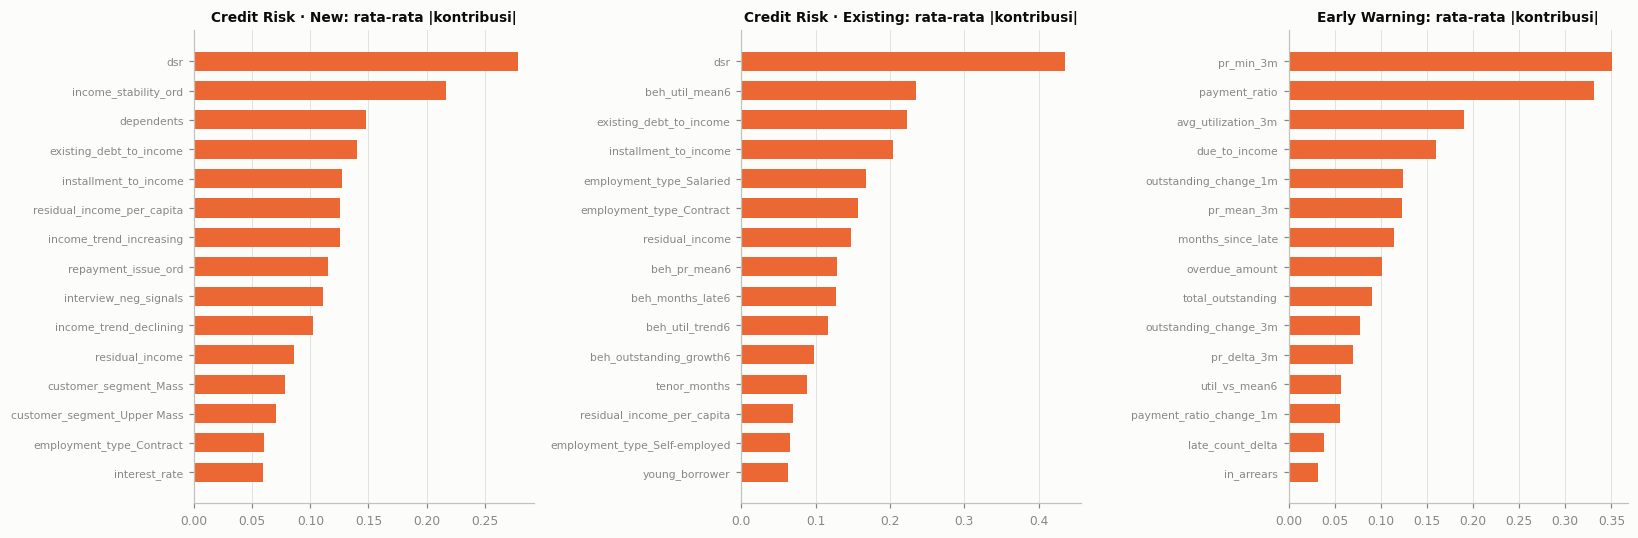

In [39]:
def contributions(model, X, max_rows=3000):
    X = X.iloc[:max_rows]
    if isinstance(model, XGBClassifier):
        dm = xgb.DMatrix(X.to_numpy(dtype=float), feature_names=list(X.columns))
        return pd.DataFrame(model.get_booster().predict(dm, pred_contribs=True)[:, :-1], columns=X.columns)
    if isinstance(model, Pipeline):
        z = model.named_steps["scaler"].transform(X)
        return pd.DataFrame(z * model.named_steps["clf"].coef_[0], columns=X.columns)
    try:
        import shap
        sv = shap.TreeExplainer(model).shap_values(X.iloc[:500], check_additivity=False)
        sv = sv[1] if isinstance(sv, list) else (sv[..., 1] if np.ndim(sv) == 3 else sv)
        return pd.DataFrame(sv, columns=X.columns)
    except Exception as e:
        print("shap tidak tersedia untuk RF:", e)
        return None


CONTRIB = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, task in zip(axes, TASK_IDS):
    b = best_rows.loc[task]
    model = fitted[(task, b.feature_set, b.model)]
    c = contributions(model, DATA[task]["X_test"][b.feature_set])
    CONTRIB[task] = c
    if c is None:
        ax.axis("off")
        continue
    imp = c.abs().mean().sort_values().tail(15)
    ax.barh(imp.index, imp.values, color=C_BAD, height=.65)
    ax.set_title(f"{TASK_NAMES[task]}: rata-rata |kontribusi|", fontsize=9)
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### 9.1 Contoh penjelasan lokal: satu pemohon new applicant berisiko tinggi
Oranye = mendorong risiko naik, biru = menurunkan risiko. Inilah bahan yang akan dinarasikan GenAI.

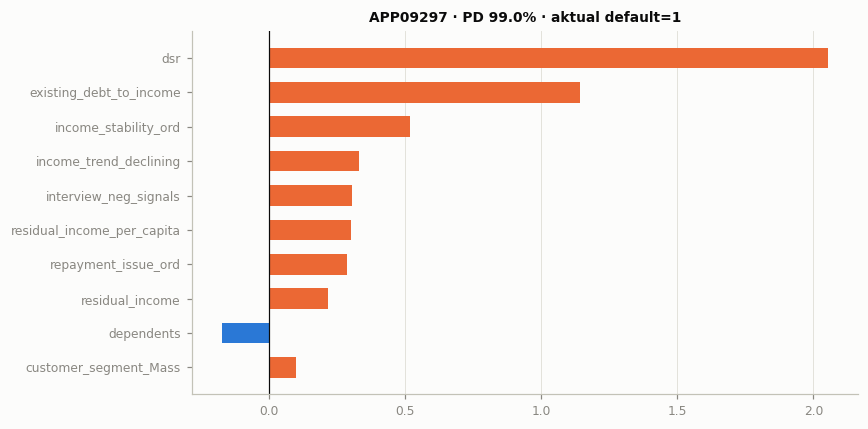

,nilai,kontribusi
dsr,1.2790,2.0525
existing_debt_to_income,1.0250,1.1417
income_stability_ord,2.0000,0.5168
income_trend_declining,1.0000,0.3309
interview_neg_signals,5.0000,0.3061
residual_income_per_capita,"-2,456,000.0000",0.3011
repayment_issue_ord,2.0000,0.2890
residual_income,"-2,456,000.0000",0.2171
dependents,0.0000,-0.1719
customer_segment_Mass,1.0000,0.1017


In [40]:
task = "cr_new"
b = best_rows.loc[task]
p = test_preds[(task, b.feature_set, b.model)]
y = DATA[task]["y_test"]
c = CONTRIB[task]
if c is not None:
    idx = int(np.argmax(np.where(y[:len(c)] == 1, p[:len(c)], -1)))
    row = c.iloc[idx]
    top = row.reindex(row.abs().sort_values(ascending=False).index[:10]).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(top.index, top.values, color=[C_BAD if v > 0 else C_GOOD for v in top.values], height=.6)
    ax.axvline(0, color=INK, lw=.8)
    meta = DATA[task]["meta_test"].iloc[idx]
    ax.set_title(f"{meta.application_id} · PD {p[idx]:.1%} · aktual default={y[idx]}", fontsize=9)
    ax.grid(axis="y", visible=False)
    plt.tight_layout()
    plt.show()
    x_raw = DATA[task]["X_test"][b.feature_set].iloc[idx]
    display(pd.DataFrame({"nilai": x_raw[top.index[::-1]], "kontribusi": top[::-1]}))

### 9.2 Kumpulkan hasil untuk guardrail, monitoring & dashboard (in-memory)

In [41]:
registry = {"run_id": RUN_ID, "created": time.strftime("%Y-%m-%d %H:%M"), "xgb_device": XGB_DEVICE, "tasks": {}}
for task in TASK_IDS:
    b = best_rows.loc[task]
    registry["tasks"][task] = {"model": b.model, "feature_set": b.feature_set, "threshold": float(b.threshold),
                               "file": f"model_{task}.joblib",
                               "test_metrics": {k[5:]: float(b[k]) for k in b.index if k.startswith("test_")}}
# peluang deteriorasi berlanjut ke default dalam 3 bulan (dipakai untuk kerugian ekspektasi EW)
registry["ew_pd_given_deterioration"] = float(
    DATA["ew"]["meta_train"].loc[DATA["ew"]["y_train"] == 1, "default_next_3m"].mean())

preds = {}
for task in TASK_IDS:
    df = DATA[task]["meta_test"].copy()
    df["y"] = DATA[task]["y_test"]
    for fs in ("baseline", "fe"):
        for name in MODELS:
            df[f"p__{name}__{fs}"] = test_preds[(task, fs, name)]
    preds[task] = df
thresholds = {f"{r.task}|{r.model}|{r.feature_set}": float(r.threshold) for r in R.itertuples()}
print(json.dumps({t: {k: v for k, v in r.items() if k != "test_metrics"} for t, r in registry["tasks"].items()}, indent=1))

{
 "cr_new": {
  "model": "LogReg",
  "feature_set": "fe",
  "threshold": 0.5357430412621937,
  "file": "model_cr_new.joblib"
 },
 "cr_existing": {
  "model": "LogReg",
  "feature_set": "fe",
  "threshold": 0.5676111606132316,
  "file": "model_cr_existing.joblib"
 },
 "ew": {
  "model": "XGBoost",
  "feature_set": "fe",
  "threshold": 0.5086531639099121,
  "file": "model_ew.joblib"
 }
}


## 10. Output Guardrail
Skor model belum boleh langsung jadi keputusan. Sebelum sampai ke analis, setiap skor lewat empat pengecekan:
1. **Validitas skor**: probabilitas harus finite dan di rentang [0, 1]. Threshold harus di dalam kebijakan [0,05; 0,95].
2. **Out-of-distribution (OOD)**: input dengan ≥ 2 fitur di luar rentang data train (persentil 0,5–99,5) ditandai.
   Model tidak pernah "melihat" profil seperti itu, jadi skornya kurang bisa dipercaya.
3. **Zona Further Review**: skor yang terlalu dekat dengan threshold (± `REVIEW_BAND`) atau OOD tidak diputuskan
   otomatis, tapi diarahkan ke analis. Ini persis cabang *Further Review* di flowchart ICA.
4. **Fairness (four-fifths rule)**: rasio tingkat persetujuan antar kelompok gender dan kota harus ≥ 0,8.
   Atribut sensitif tidak dipakai sebagai fitur, tapi hasilnya tetap diaudit.

✅ [ML·Output] cr_new: skor finite & dalam [0,1]
✅ [ML·Output] cr_new: threshold dalam kebijakan (0.05, 0.95) — 0.536
✅ [ML·Output] cr_new: proporsi input OOD tidak melonjak — test 1.8% vs train 1.6%
✅ [ML·Output] cr_new: disparate impact gender ≥ 0.8 — DI=0.97
✅ [ML·Output] cr_new: disparate impact city ≥ 0.8 — DI=0.91
✅ [ML·Output] cr_existing: skor finite & dalam [0,1]
✅ [ML·Output] cr_existing: threshold dalam kebijakan (0.05, 0.95) — 0.568
✅ [ML·Output] cr_existing: proporsi input OOD tidak melonjak — test 2.0% vs train 2.9%
✅ [ML·Output] cr_existing: disparate impact gender ≥ 0.8 — DI=0.99
✅ [ML·Output] cr_existing: disparate impact city ≥ 0.8 — DI=0.94
✅ [ML·Output] ew: skor finite & dalam [0,1]
✅ [ML·Output] ew: threshold dalam kebijakan (0.05, 0.95) — 0.509
✅ [ML·Output] ew: proporsi input OOD tidak melonjak — test 3.2% vs train 3.1%
✅ [ML·Output] ew: disparate impact gender ≥ 0.8 — DI=0.96
✅ [ML·Output] ew: disparate impact city ≥ 0.8 — DI=0.95


,task,keputusan,jumlah,porsi,rate_positif_aktual
0,cr_new,Approve,566,0.7080,0.0510
1,cr_new,Further Review,91,0.1140,0.1760
2,cr_new,Reject,143,0.1790,0.3430
3,cr_existing,Approve,1155,0.7220,0.0350
4,cr_existing,Further Review,192,0.1200,0.1560
5,cr_existing,Reject,253,0.1580,0.2770
6,ew,Alert,7604,0.2120,0.2370
7,ew,Aman,23210,0.6470,0.0410
8,ew,Further Review,5061,0.1410,0.1200


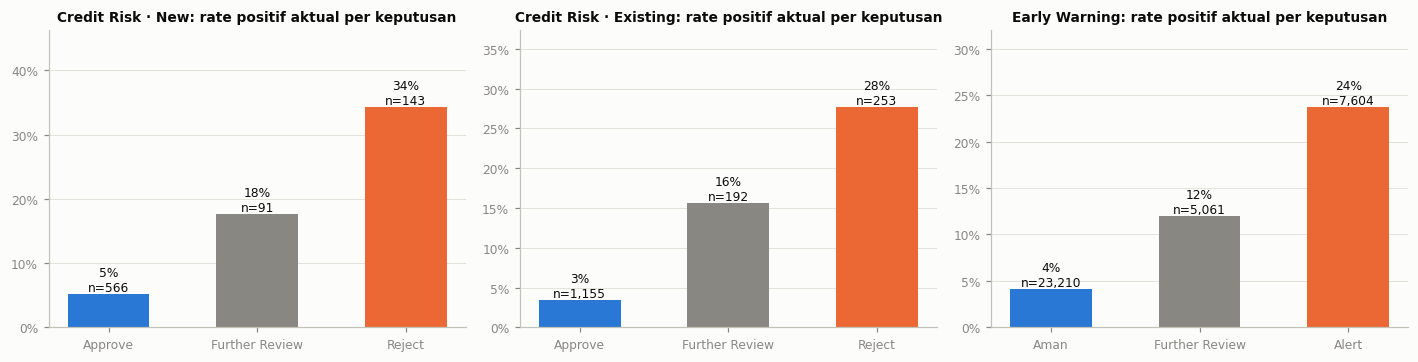

In [42]:
REVIEW_BAND = 0.05
OOD_MIN_FEATURES = 2
THR_POLICY = (0.05, 0.95)
DI_MIN = 0.80
DECISION_LABELS = {"cr": ("Approve", "Reject"), "ew": ("Aman", "Alert")}


def ood_flags(Xtr, X, q=(0.005, 0.995)):
    lo, hi = Xtr.quantile(q[0]), Xtr.quantile(q[1])
    return ((X < lo) | (X > hi)).sum(axis=1).to_numpy() >= OOD_MIN_FEATURES


def disparate_impact(rate_by_group):
    r = rate_by_group[rate_by_group.index.notna()]
    return float(r.min() / r.max()) if r.max() > 0 else 1.0


DECISIONS, out_rows = {}, []
for task in TASK_IDS:
    b = best_rows.loc[task]
    fs, thr = b.feature_set, float(b.threshold)
    p = test_preds[(task, fs, b.model)]
    Xtr, Xte = DATA[task]["X_train"][fs], DATA[task]["X_test"][fs]
    y, meta = DATA[task]["y_test"], DATA[task]["meta_test"]
    kind = "ew" if task == "ew" else "cr"
    neg_lbl, pos_lbl = DECISION_LABELS[kind]

    guard("ML", "Output", f"{task}: skor finite & dalam [0,1]", bool(np.isfinite(p).all() and (p >= 0).all() and (p <= 1).all()))
    guard("ML", "Output", f"{task}: threshold dalam kebijakan {THR_POLICY}", THR_POLICY[0] <= thr <= THR_POLICY[1], f"{thr:.3f}")

    ood_tr, ood_te = ood_flags(Xtr, Xtr).mean(), ood_flags(Xtr, Xte)
    guard("ML", "Output", f"{task}: proporsi input OOD tidak melonjak", ood_te.mean() <= max(2 * ood_tr, 0.02),
          f"test {ood_te.mean():.1%} vs train {ood_tr:.1%}", severity="warn")

    decision = np.select([ood_te, p >= thr + REVIEW_BAND, p < thr - REVIEW_BAND],
                         ["Further Review", pos_lbl, neg_lbl], "Further Review")
    d = meta.copy()
    d["y"], d["score"], d["ood"], d["decision"] = y, p, ood_te, decision
    DECISIONS[task] = d
    for dec, g in d.groupby("decision"):
        out_rows.append({"task": task, "keputusan": dec, "jumlah": len(g), "porsi": len(g) / len(d),
                         "rate_positif_aktual": g.y.mean()})

    if "gender" in d:
        approve = pd.Series(p < thr, index=d.index)
        for attr in ["gender", "city"]:
            di = disparate_impact(approve.groupby(d[attr]).mean())
            guard("ML", "Output", f"{task}: disparate impact {attr} ≥ {DI_MIN}", di >= DI_MIN, f"DI={di:.2f}",
                  severity="warn")

DEC = pd.DataFrame(out_rows)
display(DEC.round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, task in zip(axes, TASK_IDS):
    sub = DEC[DEC.task == task].set_index("keputusan")
    kind = "ew" if task == "ew" else "cr"
    order = [DECISION_LABELS[kind][0], "Further Review", DECISION_LABELS[kind][1]]
    sub = sub.reindex([o for o in order if o in sub.index])
    bars = ax.bar(sub.index, sub.rate_positif_aktual, color=[C_GOOD, MUTED, C_BAD][:len(sub)], width=.55)
    for bb, (n, r) in zip(bars, zip(sub.jumlah, sub.rate_positif_aktual)):
        ax.text(bb.get_x() + bb.get_width() / 2, r, f"{r:.0%}\nn={n:,}", ha="center", va="bottom", fontsize=8, color=INK)
    ax.set_title(f"{TASK_NAMES[task]}: rate positif aktual per keputusan", fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_ylim(0, sub.rate_positif_aktual.max() * 1.35)
    ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

Interpretasi: kelompok *Further Review* berisi kasus yang tingkat risikonya di antara Approve dan Reject.
Itu memang kasus yang paling butuh pertimbangan manusia. Di produksi, kasus ini yang diberikan ke Agentic AI
untuk diinvestigasi (riwayat kredit, pembayaran, exposure) sebelum analis memutuskan.

## 11. Monitoring & Audit
### 11.1 Drift baseline (Population Stability Index)
PSI membandingkan distribusi skor dan fitur penting antara data train (referensi) dan data baru.
Panduan: < 0,10 stabil · 0,10–0,25 perlu diperhatikan · > 0,25 drift signifikan (model perlu dievaluasi ulang).
Di sini data test dipakai sebagai "data baru". Bin referensinya disimpan ke `monitoring_baseline.json`,
supaya data produksi atau data test eksternal nanti bisa dibandingkan dengan cara yang sama.

In [43]:
def psi_baseline(ref, bins=10):
    edges = np.unique(np.quantile(ref, np.linspace(0, 1, bins + 1)))
    edges[0], edges[-1] = -np.inf, np.inf
    exp = np.histogram(ref, edges)[0] / len(ref)
    return edges, exp


def jedges(edges):
    return [None if not np.isfinite(x) else float(x) for x in edges]   # ±inf -> null (JSON valid)


def psi(edges, exp, new):
    act = np.histogram(new, edges)[0] / len(new)
    e, a = np.clip(exp, 1e-6, None), np.clip(act, 1e-6, None)
    return float(((a - e) * np.log(a / e)).sum())


baseline, psi_rows = {}, []
for task in TASK_IDS:
    b = best_rows.loc[task]
    fs = b.feature_set
    ref_score = OOF[(task, fs, b.model)]
    new_score = test_preds[(task, fs, b.model)]
    edges, exp = psi_baseline(ref_score)
    baseline[task] = {"score": {"edges": jedges(edges), "expected": exp.tolist()}, "features": {}}
    v = psi(edges, exp, new_score)
    psi_rows.append({"task": task, "variabel": "SKOR MODEL", "psi": v})
    guard("ML", "Monitoring", f"{task}: PSI skor < 0.10", v < 0.10, f"PSI={v:.3f}", severity="warn")
    imp = CONTRIB[task].abs().mean().sort_values(ascending=False).index[:5] if CONTRIB[task] is not None \
        else DATA[task]["X_train"][fs].columns[:5]
    for f in imp:
        e_, x_ = psi_baseline(DATA[task]["X_train"][fs][f].to_numpy())
        baseline[task]["features"][f] = {"edges": jedges(e_), "expected": x_.tolist()}
        psi_rows.append({"task": task, "variabel": f, "psi": psi(e_, x_, DATA[task]["X_test"][fs][f].to_numpy())})
PSI = pd.DataFrame(psi_rows)
PSI["status"] = pd.cut(PSI.psi, [-1, .1, .25, 99], labels=["stabil", "perhatikan", "drift"])
display(PSI.round(4))
(ART_DIR / "monitoring_baseline.json").write_text(json.dumps(baseline))

✅ [ML·Monitoring] cr_new: PSI skor < 0.10 — PSI=0.016
✅ [ML·Monitoring] cr_existing: PSI skor < 0.10 — PSI=0.007
✅ [ML·Monitoring] ew: PSI skor < 0.10 — PSI=0.002


,task,variabel,psi,status
0,cr_new,SKOR MODEL,0.0155,stabil
1,cr_new,dsr,0.0246,stabil
2,cr_new,income_stability_ord,0.0002,stabil
3,cr_new,dependents,0.0092,stabil
4,cr_new,existing_debt_to_income,0.0205,stabil
5,cr_new,installment_to_income,0.0135,stabil
6,cr_existing,SKOR MODEL,0.0070,stabil
7,cr_existing,dsr,0.0074,stabil
8,cr_existing,beh_util_mean6,0.0098,stabil
9,cr_existing,existing_debt_to_income,0.0104,stabil


5168

### 11.2 Model card & penyimpanan artefak
Model card merangkum tujuan, data, metrik, threshold, guardrail, dan keterbatasan. Isinya juga jadi konteks GenAI nanti.
Artefak disimpan untuk notebook GenAI / Agentic AI: model terbaik per task, prediksi, keputusan,
baseline monitoring, model card, dan audit log.

In [44]:
model_card = {
    "name": "ICA Credit Risk & Early Warning", "version": RUN_ID,
    "intended_use": "Alat bantu credit analyst. Bukan keputusan otomatis; keputusan akhir (Approve/Reject/Further Review) oleh analis.",
    "data": {"source": DATA_FOLDER, "fingerprint": fingerprint},
    "labels": {"credit_risk": "default_12m = DPD >= 90 dalam 12 bulan setelah pencairan",
               "early_warning": "deterioration_next_1m = bucket DPD bulan depan memburuk"},
    "models": {t: {"algorithm": best_rows.loc[t, "model"], "feature_set": best_rows.loc[t, "feature_set"],
                   "threshold": float(best_rows.loc[t, "threshold"]),
                   "n_features": int(best_rows.loc[t, "n_features"]),
                   "test_metrics": {k[5:]: round(float(best_rows.loc[t, k]), 4) for k in best_rows.columns if k.startswith("test_")}}
               for t in TASK_IDS},
    "guardrails": {"review_band": REVIEW_BAND, "ood_min_features": OOD_MIN_FEATURES, "threshold_policy": THR_POLICY,
                   "disparate_impact_min": DI_MIN, "excluded_sensitive_attributes": SENSITIVE, "strict_mode": STRICT},
    "limitations": ["Data sintetis; perlu validasi ulang pada data riil.",
                    "Hanya aplikasi yang disetujui (tanpa reject inference).",
                    "Asumsi bisnis (LGD, cost of fund, biaya alert) perlu dikonfirmasi tim risiko."],
}
(ART_DIR / "model_card.json").write_text(json.dumps(model_card, indent=2, ensure_ascii=False, default=str))

for task in TASK_IDS:
    b = best_rows.loc[task]
    joblib.dump({"model": fitted[(task, b.feature_set, b.model)], "features": DATA[task]["features"][b.feature_set],
                 "threshold": float(b.threshold), "model_name": b.model, "feature_set": b.feature_set,
                 "train_quantiles": DATA[task]["X_train"][b.feature_set].quantile([.005, .995])},
                ART_DIR / f"model_{task}.joblib")
joblib.dump({"preds": preds, "thresholds": thresholds, "registry": registry, "decisions": DECISIONS},
            ART_DIR / "test_predictions.joblib", compress=3)
(ART_DIR / "model_registry.json").write_text(json.dumps(registry, indent=2))
AUDIT.log("ML", "Monitoring", "artefak_disimpan", "pass", ", ".join(sorted(p.name for p in ART_DIR.iterdir())))
print(json.dumps(model_card["models"], indent=1))

{
 "cr_new": {
  "algorithm": "LogReg",
  "feature_set": "fe",
  "threshold": 0.5357430412621937,
  "n_features": 46,
  "test_metrics": {
   "roc_auc": 0.8091,
   "pr_auc": 0.4071,
   "recall": 0.5745,
   "precision": 0.2903,
   "f1": 0.3857,
   "f2": 0.4804,
   "recall@0.5": 0.6596
  }
 },
 "cr_existing": {
  "algorithm": "LogReg",
  "feature_set": "fe",
  "threshold": 0.5676111606132316,
  "n_features": 50,
  "test_metrics": {
   "roc_auc": 0.8107,
   "pr_auc": 0.3438,
   "recall": 0.6214,
   "precision": 0.2589,
   "f1": 0.3655,
   "f2": 0.4855,
   "recall@0.5": 0.7071
  }
 },
 "ew": {
  "algorithm": "XGBoost",
  "feature_set": "fe",
  "threshold": 0.5086531639099121,
  "n_features": 25,
  "test_metrics": {
   "roc_auc": 0.7754,
   "pr_auc": 0.3336,
   "recall": 0.6561,
   "precision": 0.221,
   "f1": 0.3307,
   "f2": 0.4708,
   "recall@0.5": 0.6645
  }
 }
}


## 12. Dashboard optimasi threshold & bisnis
Dashboard interaktif untuk memilih threshold Credit Risk dan Early Warning berdasarkan dampak bisnis.

**Kenapa HTML/JavaScript, bukan Dash?** Notebook jalan di runtime Colab (remote). Dash butuh server di
`localhost:8050` milik runtime itu, yang tidak bisa dijangkau dari VS Code di laptop. Dashboard ini
self-contained: semua perhitungan jalan di browser, slider responsif, dan file HTML-nya bisa dibuka di browser
mana pun atau dibagikan.

| Tab | Unit | KPI |
|---|---|---|
| Credit Risk | aplikasi (test set new + existing) | Tingkat Persetujuan · Rasio NPL · Kerugian Ekspektasi · Estimasi Profit · Disetujui/Ditolak |
| Early Warning | nasabah-bulan (test set) | Tingkat Tanpa Alert · Rasio Lolos Deteriorasi · Kerugian Ekspektasi · Ekspektasi Kerugian Tercegah · Aman/Alert |

**Rumus**
- CR: ditolak jika PD ≥ threshold. NPL = FN / disetujui. Kerugian = Σ<sub>FN</sub> plafon × LGD.
  Profit = Σ<sub>TN</sub> plafon × (bunga − cost of fund) × min(horizon, tenor) − kerugian.
- EW: alert jika skor ≥ threshold. Rasio lolos = FN / (TP + FN). Kerugian = Σ<sub>FN</sub> outstanding × P(default | memburuk) × LGD.
  Kerugian tercegah = Σ<sub>TP</sub> outstanding × P(default | memburuk) × LGD × efektivitas − (TP + FP) × biaya per alert.

In [45]:
import json, html, time
import numpy as np
import pandas as pd
import joblib
from IPython.display import display, HTML

reg = registry                 # preds, thresholds, registry dari section 9.2 (in-memory)
MODELS = ["LogReg", "RandomForest", "XGBoost"]
KEYS = [f"{m}|{fs}" for fs in ("fe", "baseline") for m in MODELS]
LABELS = {f"{m}|{fs}": f"{m} · {'Feature Eng.' if fs == 'fe' else 'Baseline'}" for m in MODELS for fs in ("fe", "baseline")}
print(json.dumps({t: {k: v for k, v in r.items() if k != "test_metrics"} for t, r in reg["tasks"].items()}, indent=1))

{
 "cr_new": {
  "model": "LogReg",
  "feature_set": "fe",
  "threshold": 0.5357430412621937,
  "file": "model_cr_new.joblib"
 },
 "cr_existing": {
  "model": "LogReg",
  "feature_set": "fe",
  "threshold": 0.5676111606132316,
  "file": "model_cr_existing.joblib"
 },
 "ew": {
  "model": "XGBoost",
  "feature_set": "fe",
  "threshold": 0.5086531639099121,
  "file": "model_ew.joblib"
 }
}


### 12.1 Siapkan data untuk dashboard

In [46]:
cr = pd.concat([preds["cr_new"], preds["cr_existing"]], ignore_index=True)
ew = preds["ew"]


def probs(df):
    return {f"{m}|{fs}": np.round(df[f"p__{m}__{fs}"].to_numpy(), 6).tolist() for m in MODELS for fs in ("fe", "baseline")}


best = {t: f"{reg['tasks'][t]['model']}|{reg['tasks'][t]['feature_set']}" for t in reg["tasks"]}
payload = {
    "labels": LABELS,
    "subtitle": (f"Data uji (hold-out) · {len(cr):,} aplikasi & {len(ew):,} nasabah-bulan · "
                 f"model rekomendasi: CR new = {LABELS[best['cr_new']]}, CR existing = {LABELS[best['cr_existing']]}, "
                 f"EW = {LABELS[best['ew']]} · dibuat {time.strftime('%d-%m-%Y %H:%M')}"),
    "cr": {
        "y": cr.y.astype(int).tolist(), "seg": (cr.customer_status == "new").astype(int).tolist(),
        "amt": cr.requested_amount.round(-3).tolist(), "rate": cr.interest_rate.round(2).tolist(),
        "tenor": cr.tenor_months.astype(int).tolist(), "p": probs(cr), "keys": KEYS,
        "thr": {seg: {k: thresholds[f"cr_{seg}|{k}"] for k in KEYS} for seg in ("new", "existing")},
        "best": {"new": best["cr_new"], "existing": best["cr_existing"]},
    },
    "ew": {
        "y": ew.y.astype(int).tolist(), "out": (ew.total_outstanding / 1e3).round().astype(int).tolist(),
        "p": probs(ew), "keys": KEYS, "thr": {k: thresholds[f"ew|{k}"] for k in KEYS}, "best": best["ew"],
        "pd_det": reg["ew_pd_given_deterioration"],
    },
}
print(f"CR rows={len(cr):,} | EW rows={len(ew):,} | P(default | memburuk) = {reg['ew_pd_given_deterioration']:.1%}")

CR rows=2,400 | EW rows=35,875 | P(default | memburuk) = 12.6%


### 12.2 Template dashboard (HTML + JavaScript, tanpa library eksternal)

In [47]:
TEMPLATE = r'''<!doctype html>
<html lang="id">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>ICA Threshold Dashboard</title>
<style>
:root{
  --bg:#f9f9f7;--surface:#fcfcfb;--card:#ffffff;--ink:#0b0b0b;--ink2:#52514e;--muted:#898781;
  --grid:#e1e0d9;--axis:#c3c2b7;--border:rgba(11,11,11,.10);--accent:#2a78d6;--line:#2a78d6;--line2:#eb6834;
  --good:#006300;--bad:#d03b3b;
  --cm0:#cde2fb;--cm1:#9ec5f4;--cm2:#6da7ec;--cm3:#2a78d6;--cm4:#184f95;
}
@media (prefers-color-scheme: dark){
  :root:not([data-theme="light"]){
    --bg:#0d0d0d;--surface:#1a1a19;--card:#202020;--ink:#ffffff;--ink2:#c3c2b7;--muted:#898781;
    --grid:#2c2c2a;--axis:#383835;--border:rgba(255,255,255,.10);--accent:#3987e5;--line:#3987e5;--line2:#d95926;
    --good:#0ca30c;--bad:#e66767;
    --cm0:#16263b;--cm1:#104281;--cm2:#1c5cab;--cm3:#2a78d6;--cm4:#5598e7;
  }
}
:root[data-theme="dark"]{
  --bg:#0d0d0d;--surface:#1a1a19;--card:#202020;--ink:#ffffff;--ink2:#c3c2b7;--muted:#898781;
  --grid:#2c2c2a;--axis:#383835;--border:rgba(255,255,255,.10);--accent:#3987e5;--line:#3987e5;--line2:#d95926;
  --good:#0ca30c;--bad:#e66767;
  --cm0:#16263b;--cm1:#104281;--cm2:#1c5cab;--cm3:#2a78d6;--cm4:#5598e7;
}
*{box-sizing:border-box}
body{margin:0;background:var(--bg);color:var(--ink);font:14px/1.45 system-ui,-apple-system,"Segoe UI",sans-serif}
.wrap{max-width:1180px;margin:0 auto;padding:16px}
header{display:flex;justify-content:space-between;align-items:flex-end;gap:12px;flex-wrap:wrap}
h1{font-size:18px;margin:0}
.subtitle{color:var(--ink2);font-size:13px;margin-top:2px}
.tabs{display:flex;gap:2px;border-bottom:1px solid var(--border);margin:14px 0 12px}
.tab{appearance:none;border:0;background:none;padding:10px 16px;font:inherit;font-weight:600;color:var(--ink2);
  border-bottom:2px solid transparent;margin-bottom:-1px;cursor:pointer}
.tab:hover{color:var(--ink)}
.tab[aria-selected="true"]{color:var(--ink);border-bottom-color:var(--accent)}
.panel{background:var(--surface);border:1px solid var(--border);border-radius:10px;padding:14px 16px;margin-bottom:12px}
.controls{display:flex;flex-wrap:wrap;gap:12px 22px;align-items:flex-end}
.ctl{display:flex;flex-direction:column;gap:4px;font-size:12px;color:var(--ink2)}
select{font:inherit;font-size:13px;padding:6px 8px;border-radius:6px;border:1px solid var(--axis);background:var(--card);color:var(--ink)}
.seg{display:inline-flex;border:1px solid var(--axis);border-radius:6px;overflow:hidden}
.seg button{appearance:none;border:0;background:var(--card);color:var(--ink2);font:inherit;font-size:13px;padding:6px 12px;cursor:pointer}
.seg button+button{border-left:1px solid var(--axis)}
.seg button[aria-pressed="true"]{background:var(--accent);color:#fff}
.thr-head{display:flex;justify-content:space-between;align-items:center;margin-top:14px;font-size:13px;color:var(--ink2)}
.thr-head b{color:var(--ink)}
.linkbtn{appearance:none;border:0;background:none;color:var(--accent);font:inherit;font-size:12px;cursor:pointer;padding:0 0 0 8px}
.thr-row{display:flex;align-items:center;gap:14px;margin-top:6px}
.thr-row input[type=range]{flex:1;accent-color:var(--accent);height:28px}
.thr-val{font-variant-numeric:tabular-nums;font-weight:700;font-size:18px;min-width:64px;text-align:center;
  border:1px solid var(--axis);border-radius:6px;padding:4px 8px;background:var(--card)}
.ticks{display:flex;justify-content:space-between;font-size:11px;color:var(--muted);margin:0 78px 0 2px}
details{margin-top:12px}
summary{cursor:pointer;font-size:13px;color:var(--ink2)}
.assump{display:grid;grid-template-columns:repeat(auto-fit,minmax(200px,1fr));gap:10px 22px;margin-top:10px}
.assump label{display:flex;flex-direction:column;font-size:12px;color:var(--ink2);gap:2px}
.assump .row{display:flex;align-items:center;gap:8px}
.assump input{flex:1;accent-color:var(--accent)}
.assump output{font-variant-numeric:tabular-nums;color:var(--ink);font-weight:600;min-width:72px;text-align:right}
.kpis{display:grid;grid-template-columns:repeat(5,1fr);gap:10px;margin-bottom:12px}
.kpi{background:var(--card);border:1px solid var(--border);border-radius:10px;padding:12px 10px;text-align:center}
.kpi .lbl{font-size:11px;letter-spacing:.04em;text-transform:uppercase;color:var(--ink2)}
.kpi .val{font-size:24px;font-weight:700;margin-top:4px;white-space:nowrap}
.kpi .sub{font-size:11px;color:var(--muted);margin-top:2px;min-height:15px}
.val.neg{color:var(--bad)} .val.pos{color:var(--good)}
.metrics{display:flex;gap:6px 22px;flex-wrap:wrap;font-size:13px;color:var(--ink2);margin:-2px 0 12px 2px}
.metrics b{color:var(--ink);font-variant-numeric:tabular-nums}
.grid2{display:grid;grid-template-columns:minmax(0,1fr) minmax(0,1.25fr);gap:12px}
h3{font-size:14px;margin:0 0 10px}
.cm{display:grid;grid-template-columns:auto 1fr 1fr;gap:3px;font-size:12px}
.cm .hd{color:var(--ink2);text-align:center;padding:4px}
.cm .rh{color:var(--ink2);display:flex;align-items:center;justify-content:flex-end;padding-right:8px;text-align:right}
.cm .cell{border-radius:6px;padding:22px 8px;text-align:center;line-height:1.35}
.cm .cell b{font-size:18px;font-variant-numeric:tabular-nums;display:block}
.chart{position:relative}
.chart svg{display:block;width:100%;overflow:visible}
.chart .ttl{font-size:12px;color:var(--ink2);margin:2px 0 2px}
.tip{position:absolute;pointer-events:none;background:var(--card);border:1px solid var(--border);border-radius:6px;
  padding:6px 8px;font-size:12px;box-shadow:0 2px 8px rgba(0,0,0,.15);display:none;white-space:nowrap;z-index:5}
.note{font-size:12px;color:var(--muted);font-style:italic;margin-top:10px}
[hidden]{display:none!important}
@media (max-width:860px){.kpis{grid-template-columns:repeat(2,1fr)}.grid2{grid-template-columns:1fr}.ticks{margin-right:2px}}
</style>
</head>
<body>
<div class="wrap">
  <header>
    <div>
      <h1>ICA: Optimasi Threshold &amp; Dampak Bisnis</h1>
      <div class="subtitle" id="subtitle"></div>
    </div>
  </header>
  <div class="tabs" role="tablist">
    <button class="tab" role="tab" data-tab="cr" aria-selected="true">Credit Risk</button>
    <button class="tab" role="tab" data-tab="ew" aria-selected="false">Early Warning</button>
  </div>
  <section id="view"></section>
</div>

<script>
const D = __PAYLOAD__;

/* ---------- format ---------- */
const nf1 = new Intl.NumberFormat('id-ID',{minimumFractionDigits:1,maximumFractionDigits:1});
const nf0 = new Intl.NumberFormat('id-ID');
const pct = x => isFinite(x) ? nf1.format(x*100)+'%' : '–';
function rp(x){
  const s = x<0?'−':'', a=Math.abs(x);
  if(a<1) return 'Rp 0';
  if(a>=1e12) return s+'Rp '+nf1.format(a/1e12)+' T';
  if(a>=1e9)  return s+'Rp '+nf1.format(a/1e9)+' M';
  if(a>=1e6)  return s+'Rp '+nf1.format(a/1e6)+' jt';
  return s+'Rp '+nf0.format(Math.round(a/1e3))+' rb';
}

/* ---------- konfigurasi per tab ---------- */
const CFG = {
  cr: {
    intro:'Geser slider untuk mengubah threshold PD. Pemohon dengan PD ≥ threshold ditolak.',
    kpi:['Tingkat Persetujuan','Rasio NPL','Kerugian Ekspektasi','Estimasi Profit','Disetujui / Ditolak'],
    kpiSub:['','default di antara yang disetujui','FN × plafon × LGD','',''],
    pos:'Gagal Bayar', neg:'Lancar', predNeg:'Prediksi: Lancar', predPos:'Prediksi: Gagal Bayar',
    cm:{fn:'Salah Lolos',tp:'Benar Tolak',tn:'Benar Lolos',fp:'Salah Tolak'},
    chart1:'Estimasi profit vs threshold', chart2:'Rasio NPL vs threshold',
    assumptions:[
      {k:'lgd',label:'LGD (loss given default)',min:10,max:90,step:5,v:45,f:v=>v+'%'},
      {k:'cof',label:'Cost of fund',min:0,max:12,step:0.5,v:5,f:v=>nf1.format(v)+'%'},
      {k:'hor',label:'Horizon pendapatan bunga',min:1,max:5,step:1,v:1,f:v=>v+' tahun'},
    ],
    note:a=>`Asumsi: plafon, bunga & tenor aktual per aplikasi · LGD ${a.lgd}% · cost of fund ${nf1.format(a.cof)}% · `+
      `pendapatan bunga ${a.hor} tahun (maks. sepanjang tenor) · profit = bunga bersih nasabah lancar yang disetujui − kerugian default yang lolos.`
  },
  ew: {
    intro:'Geser slider untuk mengubah threshold probabilitas deteriorasi. Nasabah dengan skor ≥ threshold diberi alert.',
    kpi:['Tingkat Tanpa Alert','Rasio Lolos Deteriorasi','Kerugian Ekspektasi','Ekspektasi Kerugian Tercegah','Aman / Alert'],
    kpiSub:['','memburuk tapi tidak di-alert','FN × outstanding × PD × LGD','setelah biaya penanganan',''],
    pos:'Memburuk', neg:'Tidak memburuk', predNeg:'Prediksi: Aman', predPos:'Prediksi: Alert',
    cm:{fn:'Lolos tanpa alert',tp:'Alert tepat',tn:'Aman tepat',fp:'Alert palsu'},
    chart1:'Ekspektasi kerugian tercegah vs threshold', chart2:'Rasio lolos deteriorasi vs threshold',
    assumptions:[
      {k:'lgd',label:'LGD (loss given default)',min:10,max:90,step:5,v:45,f:v=>v+'%'},
      {k:'pd',label:'Peluang memburuk → default',min:1,max:60,step:0.5,v:Math.round(D.ew.pd_det*1000)/10,f:v=>nf1.format(v)+'%'},
      {k:'eff',label:'Efektivitas penanganan alert',min:0,max:100,step:5,v:30,f:v=>v+'%'},
      {k:'cost',label:'Biaya penanganan per alert',min:0,max:2000,step:50,v:500,f:v=>'Rp '+nf0.format(v)+' rb'},
    ],
    note:a=>`Asumsi: exposure = outstanding aktual per nasabah-bulan · peluang deteriorasi berlanjut ke default ${nf1.format(a.pd)}% (dari data train) · `+
      `LGD ${a.lgd}% · alert mencegah ${a.eff}% kerugian · biaya Rp ${nf0.format(a.cost)} rb per alert.`
  }
};

/* ---------- state ---------- */
const S = {tab:'cr', cr:{model:'best', seg:'all', a:{}}, ew:{model:'best', a:{}}};
for(const t of ['cr','ew']) for(const x of CFG[t].assumptions) S[t].a[x.k]=x.v;

/* ---------- data per pilihan ---------- */
function arrays(tab){
  const st=S[tab], d=D[tab];
  if(tab==='ew'){
    const key = st.model==='best'? d.best : st.model;
    return {y:d.y, p:d.p[key], out:d.out, idx:null};
  }
  const keep=[]; for(let i=0;i<d.y.length;i++){
    if(st.seg==='all' || (st.seg==='new')===(d.seg[i]===1)) keep.push(i);
  }
  const p = keep.map(i => d.p[st.model==='best' ? d.best[d.seg[i]===1?'new':'existing'] : st.model][i]);
  return {y:keep.map(i=>d.y[i]), p, amt:keep.map(i=>d.amt[i]), rate:keep.map(i=>d.rate[i]), tenor:keep.map(i=>d.tenor[i])};
}
function recThreshold(tab){
  const st=S[tab], d=D[tab];
  if(tab==='ew') return d.thr[st.model==='best'? d.best : st.model];
  const segs = st.seg==='all' ? ['new','existing'] : [st.seg];
  const vals = segs.map(s => d.thr[s][st.model==='best'? d.best[s] : st.model]);
  return vals.reduce((a,b)=>a+b,0)/vals.length;
}

/* ---------- evaluasi bisnis ---------- */
function evaluate(tab, A, t){
  const a=S[tab].a, n=A.y.length; let tp=0,fp=0,fn=0,tn=0,loss=0,gain=0;
  for(let i=0;i<n;i++){
    const pos = A.p[i]>=t, bad = A.y[i]===1;
    if(tab==='cr'){
      if(bad){ if(pos) tp++; else { fn++; loss += A.amt[i]*a.lgd/100; } }
      else   { if(pos) fp++; else { tn++; gain += A.amt[i]*(A.rate[i]-a.cof)/100*Math.min(a.hor, A.tenor[i]/12); } }
    } else {
      const ex = A.out[i]*1e3*a.pd/100*a.lgd/100;
      if(bad){ if(pos){ tp++; gain += ex*a.eff/100; } else { fn++; loss += ex; } }
      else   { if(pos) fp++; else tn++; }
    }
  }
  const neg=tn+fn, alerted=tp+fp;
  const r = {tp,fp,fn,tn,n,neg,alerted,loss};
  r.recall = tp/Math.max(tp+fn,1); r.precision = alerted? tp/alerted : 0;
  r.f1 = (r.precision+r.recall)? 2*r.precision*r.recall/(r.precision+r.recall):0;
  r.f2 = (4*r.precision+r.recall)? 5*r.precision*r.recall/(4*r.precision+r.recall):0;
  r.k1 = neg/n;
  if(tab==='cr'){ r.k2 = neg? fn/neg : 0; r.k4 = gain-loss; }
  else          { r.k2 = fn/Math.max(tp+fn,1); r.k4 = gain - alerted*a.cost*1e3; }
  return r;
}
const TH = Array.from({length:99},(_,i)=>(i+1)/100);
let cache = {};
function curve(tab, A){
  const key = tab+JSON.stringify([S[tab].model,S[tab].seg,S[tab].a]);
  if(!cache[key]) cache[key] = TH.map(t=>evaluate(tab,A,t));
  return cache[key];
}

/* ---------- chart (SVG, satu sumbu Y per chart) ---------- */
function niceTicks(lo,hi,n=4){
  if(lo===hi){ hi=lo+1; }
  const raw=(hi-lo)/n, mag=Math.pow(10,Math.floor(Math.log10(raw))), f=raw/mag;
  const step=(f<1.5?1:f<3?2:f<7?5:10)*mag, t=[];
  for(let v=Math.floor(lo/step)*step; v<=hi+step*1e-9; v+=step) t.push(v);
  return t;
}
function lineChart(el, ys, opt){
  const W=Math.max(el.clientWidth,280), H=150, m={l:70,r:14,t:10,b:24}, iw=W-m.l-m.r, ih=H-m.t-m.b;
  let lo=Math.min(...ys), hi=Math.max(...ys); if(opt.zero){ lo=Math.min(lo,0); }
  const ticks=niceTicks(lo,hi); lo=ticks[0]; hi=ticks[ticks.length-1];
  const X=t=>m.l+(t-0.01)/(0.98)*iw, Y=v=>m.t+ih-(v-lo)/(hi-lo||1)*ih;
  let g='';
  for(const v of ticks){ g+=`<line x1="${m.l}" x2="${W-m.r}" y1="${Y(v)}" y2="${Y(v)}" stroke="var(--grid)" stroke-width="1"/>`+
    `<text x="${m.l-8}" y="${Y(v)+4}" text-anchor="end" font-size="11" fill="var(--muted)">${opt.fmt(v)}</text>`; }
  if(lo<0 && hi>0) g+=`<line x1="${m.l}" x2="${W-m.r}" y1="${Y(0)}" y2="${Y(0)}" stroke="var(--axis)" stroke-width="1"/>`;
  for(const t of [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]) g+=`<text x="${X(t)}" y="${H-6}" text-anchor="middle" font-size="11" fill="var(--muted)">${nf1.format(t)}</text>`;
  const d = ys.map((v,i)=>(i?'L':'M')+X(TH[i]).toFixed(1)+','+Y(v).toFixed(1)).join('');
  const ci = Math.round(opt.cur*100)-1, cx=X(TH[ci]), cy=Y(ys[ci]);
  el.innerHTML = `<div class="ttl">${opt.title}</div><svg viewBox="0 0 ${W} ${H}" height="${H}" role="img" aria-label="${opt.title}">${g}
    <path d="${d}" fill="none" stroke="${opt.color}" stroke-width="2" stroke-linejoin="round"/>
    <line x1="${cx}" x2="${cx}" y1="${m.t}" y2="${m.t+ih}" stroke="var(--ink2)" stroke-dasharray="3 3" stroke-width="1"/>
    <circle cx="${cx}" cy="${cy}" r="5" fill="${opt.color}" stroke="var(--surface)" stroke-width="2"/>
    <line class="hx" x1="0" x2="0" y1="${m.t}" y2="${m.t+ih}" stroke="var(--axis)" stroke-width="1" visibility="hidden"/>
    <circle class="hd" r="4" fill="${opt.color}" visibility="hidden"/>
    <rect x="${m.l}" y="${m.t}" width="${iw}" height="${ih}" fill="transparent" style="cursor:crosshair"/></svg>
    <div class="tip"></div>`;
  const svg=el.querySelector('svg'), tip=el.querySelector('.tip'), hx=svg.querySelector('.hx'), hd=svg.querySelector('.hd');
  const idxAt = ev => { const r=svg.getBoundingClientRect(); const x=(ev.clientX-r.left)*W/r.width;
    return Math.max(0,Math.min(98,Math.round(((x-m.l)/iw*0.98+0.01)*100)-1)); };
  svg.addEventListener('mousemove',ev=>{ const i=idxAt(ev), x=X(TH[i]), y=Y(ys[i]);
    hx.setAttribute('x1',x); hx.setAttribute('x2',x); hx.setAttribute('visibility','visible');
    hd.setAttribute('cx',x); hd.setAttribute('cy',y); hd.setAttribute('visibility','visible');
    tip.style.display='block'; tip.innerHTML=`Threshold <b>${TH[i].toFixed(2).replace('.',',')}</b><br>${opt.name}: <b>${opt.fmt(ys[i])}</b><br><span style="color:var(--muted)">klik untuk pakai threshold ini</span>`;
    const r=svg.getBoundingClientRect(); const px=x*r.width/W; tip.style.left=Math.min(px+12, r.width-180)+'px'; tip.style.top='18px'; });
  svg.addEventListener('mouseleave',()=>{ tip.style.display='none'; hx.setAttribute('visibility','hidden'); hd.setAttribute('visibility','hidden'); });
  svg.addEventListener('click',ev=>opt.onPick(TH[idxAt(ev)]));
}

/* ---------- render ---------- */
const view = document.getElementById('view');
function modelOptions(tab){
  const d=D[tab]; let o = `<option value="best">Rekomendasi: ${tab==='cr' ? 'terbaik per segmen' : D.labels[d.best]}</option>`;
  for(const k of d.keys) o += `<option value="${k}">${D.labels[k]}</option>`;
  return o;
}
function build(tab){
  const c=CFG[tab], st=S[tab];
  view.innerHTML = `
  <div class="panel">
    <div style="font-size:13px;color:var(--ink2);margin-bottom:10px">${c.intro}</div>
    <div class="controls">
      <label class="ctl">Model<select id="model">${modelOptions(tab)}</select></label>
      ${tab==='cr' ? `<div class="ctl">Segmen<div class="seg" id="seg">
        <button data-v="all">Semua</button><button data-v="new">New applicant</button><button data-v="existing">Existing</button></div></div>`:''}
    </div>
    <div class="thr-head"><span>Threshold klasifikasi · rekomendasi F2 (out-of-fold): <b id="rec"></b>
      <button class="linkbtn" id="reset">pakai rekomendasi</button></span></div>
    <div class="thr-row"><input type="range" id="thr" min="0.01" max="0.99" step="0.01" aria-label="Threshold">
      <span class="thr-val" id="thrv"></span></div>
    <div class="ticks"><span>0,05</span><span>0,15</span><span>0,25</span><span>0,35</span><span>0,45</span><span>0,55</span><span>0,65</span><span>0,75</span><span>0,85</span><span>0,95</span></div>
    <details><summary>Asumsi bisnis (bisa diubah)</summary><div class="assump">
      ${c.assumptions.map(x=>`<label>${x.label}<span class="row"><input type="range" data-k="${x.k}" min="${x.min}" max="${x.max}" step="${x.step}" value="${st.a[x.k]}"><output id="o_${x.k}">${x.f(st.a[x.k])}</output></span></label>`).join('')}
    </div></details>
  </div>
  <div class="kpis">${c.kpi.map((l,i)=>`<div class="kpi"><div class="lbl">${l}</div><div class="val" id="k${i}"></div><div class="sub">${c.kpiSub[i]}</div></div>`).join('')}</div>
  <div class="metrics" id="metrics"></div>
  <div class="grid2">
    <div class="panel"><h3 id="cmt"></h3><div class="cm" id="cm"></div></div>
    <div class="panel"><h3>Trade-off threshold</h3><div class="chart" id="c1"></div><div class="chart" id="c2" style="margin-top:8px"></div></div>
  </div>
  <div class="note" id="note"></div>`;
  const sel=document.getElementById('model'); sel.value=st.model;
  sel.onchange=()=>{ st.model=sel.value; st.thr=null; update(); };
  if(tab==='cr') document.querySelectorAll('#seg button').forEach(b=>{ b.onclick=()=>{ st.seg=b.dataset.v; st.thr=null; update(); }; });
  const thr=document.getElementById('thr');
  thr.oninput=()=>{ st.thr=+thr.value; update(false); };
  document.getElementById('reset').onclick=()=>{ st.thr=null; update(false); };
  document.querySelectorAll('.assump input').forEach(inp=>{ inp.oninput=()=>{ const x=c.assumptions.find(z=>z.k===inp.dataset.k);
    st.a[x.k]=+inp.value; document.getElementById('o_'+x.k).textContent=x.f(+inp.value); update(); }; });
  update();
}
let A=null;
function update(reload=true){
  const tab=S.tab, c=CFG[tab], st=S[tab];
  if(reload || !A) A=arrays(tab);
  const rec=Math.round(recThreshold(tab)*100)/100;
  if(st.thr==null) st.thr=rec;
  document.getElementById('rec').textContent=rec.toFixed(2).replace('.',',');
  document.getElementById('thr').value=st.thr;
  document.getElementById('thrv').textContent=st.thr.toFixed(2).replace('.',',');
  if(tab==='cr') document.querySelectorAll('#seg button').forEach(b=>b.setAttribute('aria-pressed', b.dataset.v===st.seg));
  const r=evaluate(tab,A,st.thr);
  const k=[pct(r.k1), pct(r.k2), rp(r.loss), rp(r.k4), nf0.format(r.neg)+' / '+nf0.format(r.alerted)];
  k.forEach((v,i)=>{ const e=document.getElementById('k'+i); e.textContent=v; e.className='val'+(i===3?(r.k4<0?' neg':' pos'):''); });
  document.getElementById('metrics').innerHTML =
    `<span>Recall <b>${pct(r.recall)}</b></span><span>Precision <b>${pct(r.precision)}</b></span><span>F1 <b>${r.f1.toFixed(3).replace('.',',')}</b></span><span>F2 <b>${r.f2.toFixed(3).replace('.',',')}</b></span><span>Data uji: <b>${nf0.format(r.n)}</b> ${tab==='cr'?'aplikasi':'nasabah-bulan'} (${pct((r.tp+r.fn)/r.n)} positif)</span>`;
  // confusion matrix
  const mx=Math.max(r.tp,r.fp,r.fn,r.tn), shade=v=>{ const s=v/mx; return s>.75?4:s>.5?3:s>.25?2:s>.08?1:0; };
  const cell=(v,lab,code)=>{ const s=shade(v); return `<div class="cell" style="background:var(--cm${s});color:${s>=3?'#fff':'var(--ink)'}"><b>${nf0.format(v)}</b>${code} (${lab})</div>`; };
  document.getElementById('cmt').textContent=`Confusion matrix (threshold = ${st.thr.toFixed(2).replace('.',',')})`;
  document.getElementById('cm').innerHTML = `<div></div><div class="hd">${c.predNeg}</div><div class="hd">${c.predPos}</div>
    <div class="rh">Aktual: ${c.pos}</div>${cell(r.fn,c.cm.fn,'FN')}${cell(r.tp,c.cm.tp,'TP')}
    <div class="rh">Aktual: ${c.neg}</div>${cell(r.tn,c.cm.tn,'TN')}${cell(r.fp,c.cm.fp,'FP')}`;
  // charts
  const cv=curve(tab,A), pick=t=>{ st.thr=t; update(false); };
  lineChart(document.getElementById('c1'), cv.map(x=>x.k4), {title:c.chart1, name:c.kpi[3], fmt:rp, color:'var(--line)', cur:st.thr, zero:true, onPick:pick});
  lineChart(document.getElementById('c2'), cv.map(x=>x.k2), {title:c.chart2, name:c.kpi[1], fmt:v=>nf1.format(v*100)+'%', color:'var(--line2)', cur:st.thr, zero:true, onPick:pick});
  document.getElementById('note').textContent=c.note(st.a);
}
document.querySelectorAll('.tab').forEach(b=>b.onclick=()=>{
  document.querySelectorAll('.tab').forEach(x=>x.setAttribute('aria-selected', x===b));
  S.tab=b.dataset.tab; A=null; build(S.tab);
});
document.getElementById('subtitle').textContent = D.subtitle;
window.addEventListener('resize',()=>update(false));
build('cr');
</script>
</body>
</html>'''

### 12.3 Tampilkan dashboard
- Slider threshold, dropdown model (rekomendasi atau 6 model lain), segmen CR (Semua / New / Existing).
- "Asumsi bisnis" bisa dibuka untuk mengubah LGD, cost of fund, horizon, efektivitas, dan biaya alert.
- Klik titik di grafik trade-off untuk langsung memakai threshold itu.

In [48]:
page = TEMPLATE.replace("__PAYLOAD__", json.dumps(payload, separators=(",", ":")))
out_html = ART_DIR / "ica_threshold_dashboard.html"
out_html.write_text(page, encoding="utf-8")
print(f"Dashboard tersimpan: {out_html}  ({out_html.stat().st_size / 1e6:.1f} MB)")
display(HTML(f'<iframe srcdoc="{html.escape(page)}" style="width:100%;height:1080px;border:0;'
             f'border-radius:8px" sandbox="allow-scripts"></iframe>'))

Dashboard tersimpan: /content/ica_data/ICA_Synthetic_v4/ica_artifacts/ica_threshold_dashboard.html  (3.2 MB)


> Kalau output di atas tidak tampil di VS Code: buka file `ica_threshold_dashboard.html` di browser.
> File ada di folder `ica_artifacts` (di Google Drive kalau data dibaca dari Drive). Bisa juga klik kanan file
> di panel Colab, lalu download.

### 12.4 Tabel ringkasan (Python) pada beberapa threshold
Rumus sama dengan dashboard, dengan asumsi default. Berguna untuk laporan dan untuk memverifikasi angka dashboard.

In [49]:
LGD, COF, HOR = 0.45, 0.05, 1
PD_DET, EFF, COST = round(reg["ew_pd_given_deterioration"] * 100, 1) / 100, 0.30, 500_000  # dibulatkan sama seperti slider


def cr_business(df, col, t):
    rej = df[col] >= t
    y = df.y == 1
    tp, fp, fn, tn = (rej & y).sum(), (rej & ~y).sum(), (~rej & y).sum(), (~rej & ~y).sum()
    loss = (df.requested_amount * LGD)[~rej & y].sum()
    inc = (df.requested_amount * (df.interest_rate / 100 - COF) * np.minimum(HOR, df.tenor_months / 12))[~rej & ~y].sum()
    return {"threshold": t, "tingkat_persetujuan": (tn + fn) / len(df), "rasio_npl": fn / max(tn + fn, 1),
            "kerugian_ekspektasi_M": loss / 1e9, "estimasi_profit_M": (inc - loss) / 1e9,
            "disetujui": tn + fn, "ditolak": tp + fp, "recall": tp / max(tp + fn, 1), "precision": tp / max(tp + fp, 1)}


def ew_business(df, col, t):
    al = df[col] >= t
    y = df.y == 1
    tp, fp, fn, tn = (al & y).sum(), (al & ~y).sum(), (~al & y).sum(), (~al & ~y).sum()
    ex = df.total_outstanding * PD_DET * LGD
    loss, saved = ex[~al & y].sum(), ex[al & y].sum() * EFF
    return {"threshold": t, "tingkat_tanpa_alert": (tn + fn) / len(df), "rasio_lolos_deteriorasi": fn / max(tp + fn, 1),
            "kerugian_ekspektasi_M": loss / 1e9, "kerugian_tercegah_M": (saved - (tp + fp) * COST) / 1e9,
            "aman": tn + fn, "alert": tp + fp, "recall": tp / max(tp + fn, 1), "precision": tp / max(tp + fp, 1)}


cr_best = cr.copy()
cr_best["p_best"] = np.where(cr.customer_status == "new", cr[f"p__{best['cr_new'].replace('|', '__')}"],
                             cr[f"p__{best['cr_existing'].replace('|', '__')}"])
grid = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
print("Credit Risk · model rekomendasi · semua segmen")
display(pd.DataFrame([cr_business(cr_best, "p_best", t) for t in grid]).round(3))
print("Early Warning · model rekomendasi")
display(pd.DataFrame([ew_business(ew, f"p__{best['ew'].replace('|', '__')}", t) for t in grid]).round(3))

prof = pd.DataFrame([cr_business(cr_best, "p_best", t / 100) for t in range(1, 100)])
saved = pd.DataFrame([ew_business(ew, f"p__{best['ew'].replace('|', '__')}", t / 100) for t in range(1, 100)])
print(f"Threshold CR dengan profit maksimum (asumsi default): {prof.loc[prof.estimasi_profit_M.idxmax(), 'threshold']:.2f}")
print(f"Threshold EW dengan kerugian tercegah maksimum      : {saved.loc[saved.kerugian_tercegah_M.idxmax(), 'threshold']:.2f}")

Credit Risk · model rekomendasi · semua segmen


,threshold,tingkat_persetujuan,rasio_npl,kerugian_ekspektasi_M,estimasi_profit_M,disetujui,ditolak,recall,precision
0,0.2000,0.3090,0.0160,0.8860,5.7970,741,1659,0.9490,0.1340
1,0.3000,0.4660,0.0210,1.3470,8.1390,1119,1281,0.8970,0.1640
2,0.4000,0.6100,0.0320,2.5300,9.2520,1465,935,0.7990,0.2000
3,0.5000,0.7240,0.0420,3.7850,9.5060,1738,662,0.6880,0.2430
4,0.6000,0.8250,0.0540,6.4730,8.1220,1979,421,0.5470,0.3040
5,0.7000,0.8890,0.0610,7.0120,8.3870,2134,266,0.4440,0.3910
6,0.8000,0.9370,0.0730,8.3270,7.5020,2249,151,0.2990,0.4640


Early Warning · model rekomendasi


,threshold,tingkat_tanpa_alert,rasio_lolos_deteriorasi,kerugian_ekspektasi_M,kerugian_tercegah_M,aman,alert,recall,precision
0,0.2000,0.1240,0.0200,0.2720,-10.1070,4449,31426,0.9800,0.1050
1,0.3000,0.3950,0.1210,2.0920,-5.7880,14181,21694,0.8790,0.1360
2,0.4000,0.5820,0.2270,3.9430,-2.9990,20869,15006,0.7730,0.1730
3,0.5000,0.7120,0.3360,5.8160,-1.2180,25555,10320,0.6640,0.2160
4,0.6000,0.8120,0.4530,7.9290,-0.0710,29117,6758,0.5470,0.2720
5,0.7000,0.8920,0.6060,10.7480,0.5280,32005,3870,0.3940,0.3420
6,0.8000,0.9520,0.7690,14.1370,0.5800,34143,1732,0.2310,0.4470


Threshold CR dengan profit maksimum (asumsi default): 0.49
Threshold EW dengan kerugian tercegah maksimum      : 0.75


## 13. Ringkasan guardrail run ini

In [50]:
A = AUDIT.frame()
A = A[A.layer != "System"]
summary = A.pivot_table(index=["layer", "stage"], columns="status", values="check", aggfunc="count", fill_value=0)
for s in ["pass", "warn", "fail"]:
    if s not in summary:
        summary[s] = 0
display(summary[["pass", "warn", "fail"]])
warns = A[A.status != "pass"][["layer", "stage", "check", "status", "detail"]]
print(f"Total cek: {len(A)} · lolos: {(A.status == 'pass').sum()} · peringatan: {(A.status == 'warn').sum()} · "
      f"gagal: {(A.status == 'fail').sum()}")
if len(warns):
    print("\nPerlu perhatian:")
    display(warns)
print(f"\nAudit log lengkap: {AUDIT.path}")

status            pass  warn  fail
layer stage                       
Data  Input         45     0     0
      Monitoring     1     0     0
ML    Monitoring     4     0     0
      Output        15     0     0
      Process       34     1     0

Total cek: 100 · lolos: 99 · peringatan: 1 · gagal: 0

Perlu perhatian:


,layer,stage,check,status,detail
72,ML,Process,cr_new: recall test ≥ 0.6,warn,0.574



Audit log lengkap: /content/ica_data/ICA_Synthetic_v4/ica_artifacts/audit_log.jsonl


### Rencana guardrail untuk GenAI & Agentic AI (notebook berikutnya)
Fungsi `guard()`, `AUDIT`, dan `mask_pii()` di notebook ini dipakai ulang supaya semua lapisan tercatat di
satu audit log yang sama.

| Lapisan | Tahap | Cek yang akan diimplementasikan |
|---|---|---|
| GenAI (ekstraksi interview) | Input | `mask_pii()` sebelum teks ke LLM · deteksi prompt injection ("abaikan instruksi", "ignore previous") · batas panjang jawaban |
| | Process | Prompt template tetap, temperature 0, output wajib JSON sesuai skema (6 label + confidence) |
| | Output | Validasi skema & nilai kategori · confidence rendah → *Further Review* · akurasi vs label ground truth dilaporkan |
| GenAI (penjelasan skor) | Process | Konteks hanya dari evidence: skor, threshold, top kontribusi fitur, data nasabah |
| | Output | **Grounding check**: semua angka di narasi harus ada di evidence · tidak ada rekomendasi final · tidak ada PII · bahasa netral (tanpa atribut sensitif) |
| Agentic AI | Input | Klasifikasi intent (hanya pertanyaan kredit), RBAC analis, validasi `customer_id` |
| | Process | Hanya 3 tools read-only (credit history, payment history, exposure) · allowlist · maksimal N langkah & timeout · tanpa aksi tulis |
| | Output | Jawaban wajib mencantumkan tool & data sumber · disclaimer keputusan di analis |
| Semua | Monitoring | Log prompt/respons (ter-masking), setiap pemanggilan tool + parameter, tingkat blokir guardrail, keputusan & feedback analis |